# ResNet50 Facial Affect Recognition
## Multi-Task Learning: Emotion Classification + Valence/Arousal Regression

This notebook implements ResNet50 for facial affect recognition with:
- **Categorical Classification**: 8 emotion classes (0: Neutral, 1: Happy, 2: Sad, 3: Surprise, 4: Fear, 5: Disgust, 6: Anger, 7: Contempt)
- **Continuous Regression**: Valence and Arousal prediction in range [-1, +1]

### Assignment Requirements:
- Dataset: 224x224 RGB facial images with annotations in .npy files  
- Multi-task learning approach for both categorical and continuous prediction
- Comprehensive evaluation metrics for both tasks
- Optimized for Google Colab GPU training

### Dataset Structure:
- `images/`: Facial images (224x224 RGB)
- `annotations/`: Individual .npy files for each image
  - `{id}_exp.npy`: Expression labels (0-7)
  - `{id}_val.npy`: Valence values [-1, +1]
  - `{id}_aro.npy`: Arousal values [-1, +1]
  - `{id}_lnd.npy`: 68 facial landmarks

In [19]:
# Install necessary packages
!pip install tensorflow keras matplotlib seaborn scikit-learn opencv-python pillow glob tqdm pandas numpy krippendorff
!pip install krippendorff
# Note: Some of these packages might already be available in Colab's environment.
# Running this cell ensures all required dependencies are met.

ERROR: Could not find a version that satisfies the requirement glob (from versions: none)
ERROR: No matching distribution found for glob


In [20]:
# Setup and Library Imports
import sys
import os
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image
import glob
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                           cohen_kappa_score, roc_auc_score, average_precision_score,
                           mean_squared_error, f1_score, accuracy_score)
from sklearn.preprocessing import LabelBinarizer
from scipy.stats import pearsonr
import krippendorff

# Check environment and GPU
IN_COLAB = 'google.colab' in sys.modules
print(f"Running in Google Colab: {IN_COLAB}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU'))} GPU(s)")

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"GPU setup error: {e}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

Running in Google Colab: True
TensorFlow version: 2.19.0
GPU available: 1 GPU(s)
✅ GPU memory growth enabled for 1 GPU(s)


## 📂 Dataset Configuration and Path Setup

In [27]:
# Configuration
CONFIG = {
    'IMG_SIZE': 224,           # Image size (224x224 as per assignment)
    'BATCH_SIZE': 32,          # Batch size for training
    'EPOCHS': 100,             # Maximum epochs with early stopping
    'NUM_CLASSES': 8,          # Number of emotion classes
    'LEARNING_RATE': 0.0001,   # Initial learning rate
    'VALIDATION_SPLIT': 0.0,   # Validation split ratio (set to 0 for 70/30 train/test)
    'TEST_SPLIT': 0.3,         # Test split ratio (updated to 30%)
}

# Emotion class mapping as per assignment
EMOTION_CLASSES = {
    0: 'Neutral',
    1: 'Happy',
    2: 'Sad',
    3: 'Surprise',
    4: 'Fear',
    5: 'Disgust',
    6: 'Anger',
    7: 'Contempt'
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

print(f"\nEmotion Classes: {EMOTION_CLASSES}")

# Dataset paths (modify based on your setup)
if IN_COLAB:
    # For Google Colab - use the uploaded zip file
    DATASET_BASE = '/content/DL_Assignment1_Dataset/Dataset'  # Base dataset folder from extracted zip
    IMAGES_PATH = '/content/Dataset/Dataset/images'
    ANNOTATIONS_PATH = '/content/Dataset/Dataset/annotations'
    SAVE_PATH = '/content/'  # Save models and results here
else:
    # For local development
    DATASET_BASE = r'c:\Users\tariq\Downloads\Deep_Learning_Assignment_1\DL_Assignment1_Dataset\Dataset\Dataset'
    IMAGES_PATH = os.path.join(DATASET_BASE, 'images')
    ANNOTATIONS_PATH = os.path.join(DATASET_BASE, 'annotations')
    SAVE_PATH = r'c:\Users\tariq\Downloads\Deep_Learning_Assignment_1'

print(f"\nDataset Paths:")
print(f"  Base: {DATASET_BASE}")
print(f"  Images: {IMAGES_PATH}")
print(f"  Annotations: {ANNOTATIONS_PATH}")
print(f"  Save Path: {SAVE_PATH}")

# Verify paths exist
print(f"\nPath Verification:")
print(f"  Images folder exists: {os.path.exists(IMAGES_PATH)}")
print(f"  Annotations folder exists: {os.path.exists(ANNOTATIONS_PATH)}")
if os.path.exists(IMAGES_PATH):
    image_files = len(glob.glob(os.path.join(IMAGES_PATH, '*.*')))
    print(f"  Number of image files found: {image_files}")
if os.path.exists(ANNOTATIONS_PATH):
    annotation_files = len(glob.glob(os.path.join(ANNOTATIONS_PATH, '*.npy')))
    print(f"  Number of annotation files found: {annotation_files}")

Configuration:
  IMG_SIZE: 224
  BATCH_SIZE: 32
  EPOCHS: 100
  NUM_CLASSES: 8
  LEARNING_RATE: 0.0001
  VALIDATION_SPLIT: 0.0
  TEST_SPLIT: 0.3

Emotion Classes: {0: 'Neutral', 1: 'Happy', 2: 'Sad', 3: 'Surprise', 4: 'Fear', 5: 'Disgust', 6: 'Anger', 7: 'Contempt'}

Dataset Paths:
  Base: /content/DL_Assignment1_Dataset/Dataset
  Images: /content/Dataset/Dataset/images
  Annotations: /content/Dataset/Dataset/annotations
  Save Path: /content/

Path Verification:
  Images folder exists: True
  Annotations folder exists: True
  Number of image files found: 3999
  Number of annotation files found: 15996


## 🔍 Dataset Loading and Analysis

In [28]:
def load_dataset(images_path, annotations_path):
    """
    Load dataset from images and individual annotation files
    """
    print("🔍 Discovering dataset files...")

    # Get all image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(images_path, ext)))

    print(f"Found {len(image_files)} image files")

    # Extract image IDs from filenames
    image_ids = []
    for img_file in image_files:
        filename = os.path.basename(img_file)
        # Remove extension to get ID
        img_id = os.path.splitext(filename)[0]
        image_ids.append(img_id)

    print(f"Extracted {len(image_ids)} image IDs")

    # Load annotations for each image
    dataset = []
    missing_annotations = []

    print("📂 Loading annotations...")
    for i, (img_file, img_id) in enumerate(tqdm(zip(image_files, image_ids), total=len(image_files))):
        # Define annotation file paths
        exp_file = os.path.join(annotations_path, f"{img_id}_exp.npy")
        val_file = os.path.join(annotations_path, f"{img_id}_val.npy")
        aro_file = os.path.join(annotations_path, f"{img_id}_aro.npy")
        lnd_file = os.path.join(annotations_path, f"{img_id}_lnd.npy")

        # Check if all annotation files exist
        if all(os.path.exists(f) for f in [exp_file, val_file, aro_file, lnd_file]):
            try:
                # Load annotations
                expression = np.load(exp_file)
                valence = np.load(val_file)
                arousal = np.load(aro_file)
                landmarks = np.load(lnd_file)

                # Handle potential array structures
                if expression.ndim > 0:
                    expression = expression.item() if expression.size == 1 else expression[0]
                if valence.ndim > 0:
                    valence = valence.item() if valence.size == 1 else valence[0]
                if arousal.ndim > 0:
                    arousal = arousal.item() if arousal.size == 1 else arousal[0]

                # Filter out invalid valence/arousal values (-2 indicates uncertain/no-face)
                if valence != -2 and arousal != -2:
                    dataset.append({
                        'image_path': img_file,
                        'image_id': img_id,
                        'expression': int(expression),
                        'valence': float(valence),
                        'arousal': float(arousal),
                        'landmarks': landmarks
                    })
            except Exception as e:
                print(f"Error loading annotations for {img_id}: {e}")
                missing_annotations.append(img_id)
        else:
            missing_annotations.append(img_id)

    print(f"✅ Successfully loaded {len(dataset)} samples")
    if missing_annotations:
        print(f"⚠️  Missing annotations for {len(missing_annotations)} images")

    return dataset

# Load the dataset
dataset = load_dataset(IMAGES_PATH, ANNOTATIONS_PATH)
print(f"\n📊 Dataset Summary: {len(dataset)} samples loaded")

🔍 Discovering dataset files...
Found 3999 image files
Extracted 3999 image IDs
📂 Loading annotations...


100%|██████████| 3999/3999 [00:01<00:00, 2202.05it/s]

✅ Successfully loaded 3999 samples

📊 Dataset Summary: 3999 samples loaded


In [29]:
# Extract the dataset zip file
import zipfile
import os

zip_path = '/content/DL_Assignment1_Dataset.zip' # Path to the uploaded zip file
extract_path = '/content/' # Directory to extract to

# Ensure the extract path exists
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"✅ Successfully extracted {zip_path} to {extract_path}")
except FileNotFoundError:
    print(f"❌ Error: Zip file not found at {zip_path}")
except zipfile.BadZipFile:
    print(f"❌ Error: Invalid zip file at {zip_path}")
except Exception as e:
    print(f"❌ An error occurred during extraction: {e}")

# Verify extraction by listing extracted directory content
extracted_content = os.listdir(os.path.join(extract_path, 'Dataset/Dataset'))
print(f"\n📂 Content of extracted directory '/content/Dataset/Dataset':")
for item in extracted_content:
    print(f"  - {item}")

✅ Successfully extracted /content/DL_Assignment1_Dataset.zip to /content/

📂 Content of extracted directory '/content/Dataset/Dataset':
  - annotations
  - images


📈 Dataset Analysis:

🎭 Expression Distribution:
  0 (Neutral): 500 samples (12.5%)
  1 (Happy): 500 samples (12.5%)
  2 (Sad): 500 samples (12.5%)
  3 (Surprise): 500 samples (12.5%)
  4 (Fear): 500 samples (12.5%)
  5 (Disgust): 500 samples (12.5%)
  6 (Anger): 500 samples (12.5%)
  7 (Contempt): 499 samples (12.5%)

📊 Valence Statistics:
  Range: [-0.987, 0.982]
  Mean: -0.192
  Std: 0.466

📊 Arousal Statistics:
  Range: [-0.667, 0.984]
  Mean: 0.354
  Std: 0.380


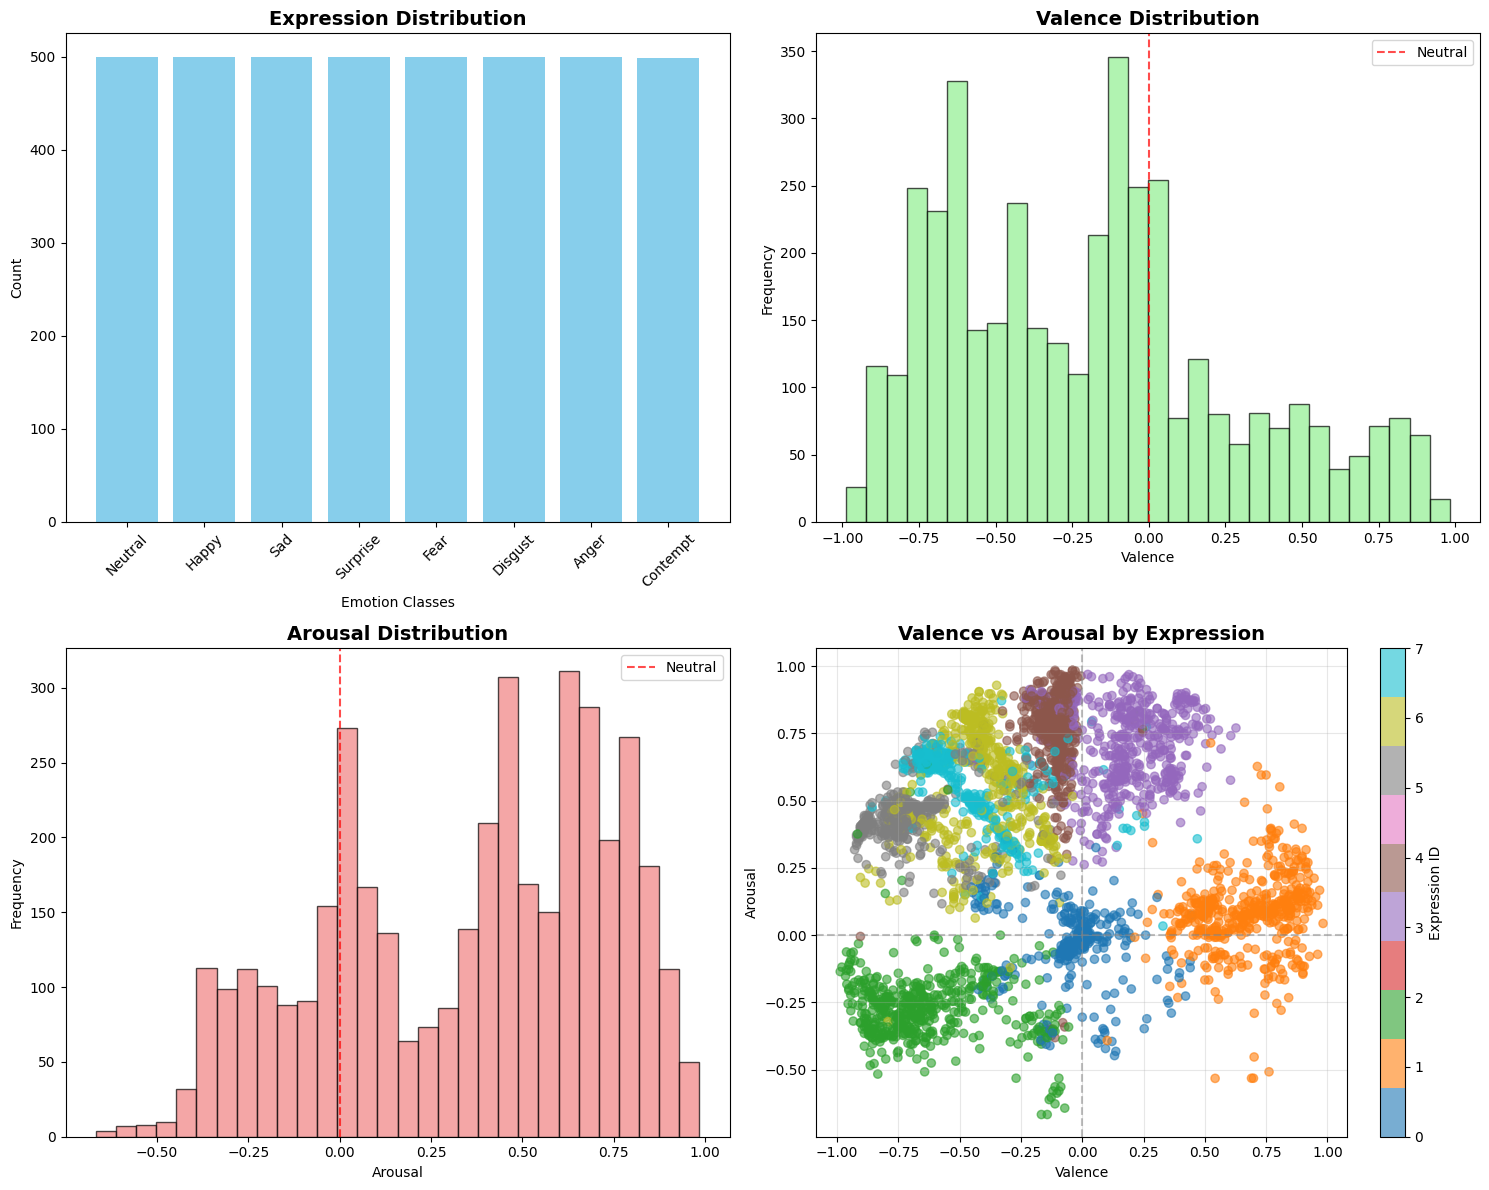


✅ Dataset analysis complete: 3999 valid samples ready for training


In [30]:
# Analyze dataset distribution
print("📈 Dataset Analysis:")
print("=" * 50)

# Convert to DataFrame for easier analysis
df = pd.DataFrame(dataset)

# Expression distribution
expression_counts = df['expression'].value_counts().sort_index()
print(f"\n🎭 Expression Distribution:")
for exp_id, count in expression_counts.items():
    emotion_name = EMOTION_CLASSES.get(exp_id, f'Class_{exp_id}')
    print(f"  {exp_id} ({emotion_name}): {count} samples ({count/len(df)*100:.1f}%)")

# Valence and Arousal statistics
print(f"\n📊 Valence Statistics:")
print(f"  Range: [{df['valence'].min():.3f}, {df['valence'].max():.3f}]")
print(f"  Mean: {df['valence'].mean():.3f}")
print(f"  Std: {df['valence'].std():.3f}")

print(f"\n📊 Arousal Statistics:")
print(f"  Range: [{df['arousal'].min():.3f}, {df['arousal'].max():.3f}]")
print(f"  Mean: {df['arousal'].mean():.3f}")
print(f"  Std: {df['arousal'].std():.3f}")

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Expression distribution
axes[0, 0].bar([EMOTION_CLASSES.get(i, f'C{i}') for i in expression_counts.index],
               expression_counts.values, color='skyblue')
axes[0, 0].set_title('Expression Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Emotion Classes')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Valence distribution
axes[0, 1].hist(df['valence'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Valence Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Valence')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Neutral')
axes[0, 1].legend()

# Arousal distribution
axes[1, 0].hist(df['arousal'], bins=30, color='lightcoral', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Arousal Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Arousal')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Neutral')
axes[1, 0].legend()

# Valence vs Arousal scatter plot
scatter = axes[1, 1].scatter(df['valence'], df['arousal'],
                           c=df['expression'], cmap='tab10', alpha=0.6)
axes[1, 1].set_title('Valence vs Arousal by Expression', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Valence')
axes[1, 1].set_ylabel('Arousal')
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)

# Add colorbar for expressions
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('Expression ID')

plt.tight_layout()
plt.show()

print(f"\n✅ Dataset analysis complete: {len(dataset)} valid samples ready for training")

## 🖼️ Image Processing and Data Preparation

In [31]:
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    """
    Load and preprocess image for ResNet50
    """
    try:
        # Load image
        img = cv2.imread(image_path)
        if img is None:
            # Try with PIL as fallback
            img = Image.open(image_path)
            img = np.array(img)
        else:
            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize to target size
        img = cv2.resize(img, target_size)

        # Convert to float32 and normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        return img
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        # Return a black image as fallback
        return np.zeros((*target_size, 3), dtype=np.float32)

# Load all images and create arrays
print("🖼️ Loading and preprocessing images...")
print("This may take several minutes for large datasets...")

images = []
expressions = []
valences = []
arousals = []
landmarks_list = []

# Use tqdm for progress tracking
for i, sample in enumerate(tqdm(dataset, desc="Loading images")):
    # Load and preprocess image
    img = load_and_preprocess_image(sample['image_path'], (CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']))

    images.append(img)
    expressions.append(sample['expression'])
    valences.append(sample['valence'])
    arousals.append(sample['arousal'])
    landmarks_list.append(sample['landmarks'])

# Convert to numpy arrays
X_images = np.array(images)
y_expressions = np.array(expressions)
y_valences = np.array(valences)
y_arousals = np.array(arousals)
X_landmarks = np.array(landmarks_list)

print(f"\n✅ Data loading complete!")
print(f"  Images shape: {X_images.shape}")
print(f"  Expressions shape: {y_expressions.shape}")
print(f"  Valences shape: {y_valences.shape}")
print(f"  Arousals shape: {y_arousals.shape}")
print(f"  Landmarks shape: {X_landmarks.shape}")
print(f"  Memory usage: {X_images.nbytes / 1024**2:.2f} MB (images)")

# Clean up
del images
print("🧹 Cleaned up temporary variables")

🖼️ Loading and preprocessing images...
This may take several minutes for large datasets...


Loading images: 100%|██████████| 3999/3999 [00:03<00:00, 1252.19it/s]



✅ Data loading complete!
  Images shape: (3999, 224, 224, 3)
  Expressions shape: (3999,)
  Valences shape: (3999,)
  Arousals shape: (3999,)
  Landmarks shape: (3999, 136)
  Memory usage: 2296.30 MB (images)
🧹 Cleaned up temporary variables


👀 Sample Images from Dataset:


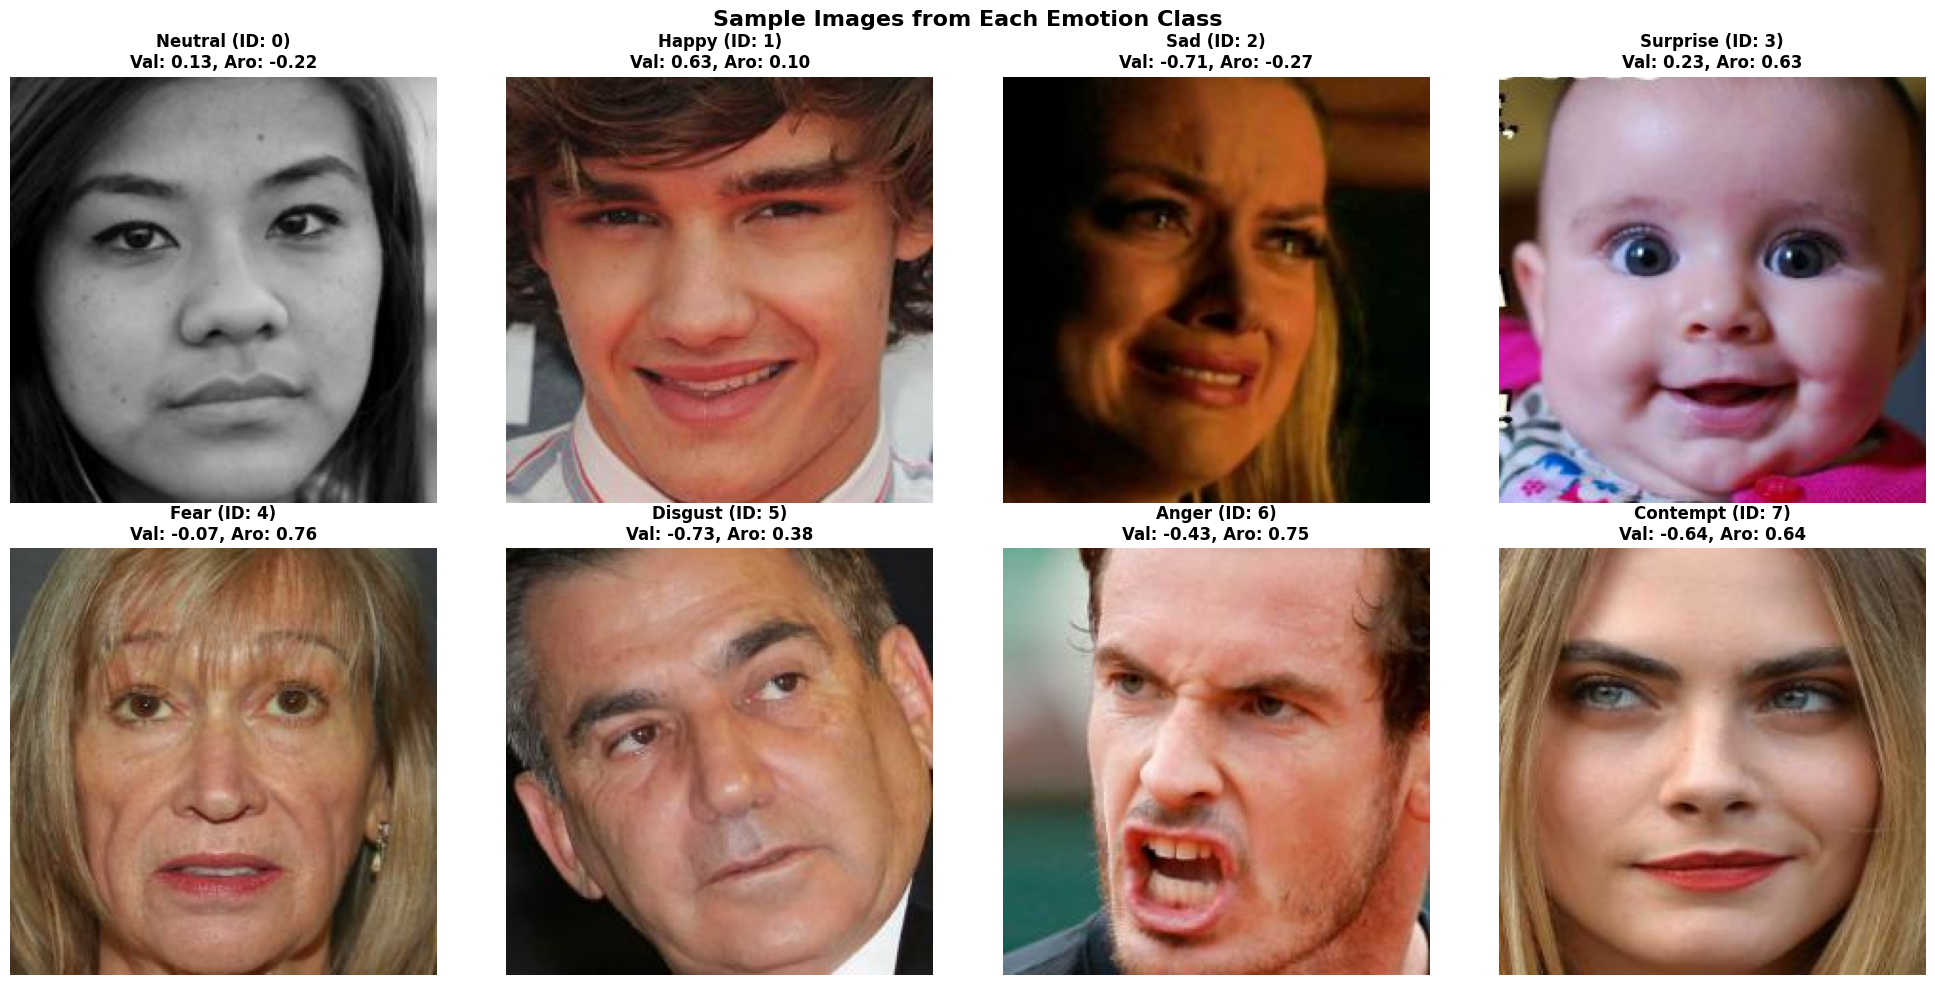


🔍 Data Integrity Check:
  Expression range: [0, 7]
  Valence range: [-0.987, 0.982]
  Arousal range: [-0.667, 0.984]
  Image value range: [0.000, 1.000]
  All images same shape: True
✅ Data preparation complete!


In [32]:
# Display sample images
print("👀 Sample Images from Dataset:")

# Select random samples from each emotion class
sample_indices = []
for emotion_id in range(CONFIG['NUM_CLASSES']):
    emotion_indices = np.where(y_expressions == emotion_id)[0]
    if len(emotion_indices) > 0:
        sample_idx = np.random.choice(emotion_indices)
        sample_indices.append(sample_idx)

# Display samples
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, idx in enumerate(sample_indices):
    if i < len(axes):
        # Display image
        axes[i].imshow(X_images[idx])
        axes[i].axis('off')

        # Get sample info
        emotion_id = y_expressions[idx]
        emotion_name = EMOTION_CLASSES.get(emotion_id, f'Class_{emotion_id}')
        valence = y_valences[idx]
        arousal = y_arousals[idx]

        # Set title with emotion and valence/arousal
        axes[i].set_title(
            f'{emotion_name} (ID: {emotion_id})\n'
            f'Val: {valence:.2f}, Aro: {arousal:.2f}',
            fontsize=12, fontweight='bold'
        )

plt.suptitle('Sample Images from Each Emotion Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Verify data integrity
print(f"\n🔍 Data Integrity Check:")
print(f"  Expression range: [{y_expressions.min()}, {y_expressions.max()}]")
print(f"  Valence range: [{y_valences.min():.3f}, {y_valences.max():.3f}]")
print(f"  Arousal range: [{y_arousals.min():.3f}, {y_arousals.max():.3f}]")
print(f"  Image value range: [{X_images.min():.3f}, {X_images.max():.3f}]")
print(f"  All images same shape: {np.all([img.shape == (CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'], 3) for img in X_images])}")

print("✅ Data preparation complete!")

## 🔀 Data Splitting and Augmentation

In [33]:
# Split the data into train, validation, and test sets
print("🔀 Splitting dataset...")

# Split: 70% train, 30% test
X_train, X_test, y_exp_train, y_exp_test, y_val_train, y_val_test, y_aro_train, y_aro_test = train_test_split(
    X_images, y_expressions, y_valences, y_arousals,
    test_size=CONFIG['TEST_SPLIT'],
    random_state=42,
    stratify=y_expressions  # Stratify by expression to maintain class balance
)

# No validation set for 70/30 split, use test set for validation metrics during training
X_val = X_test
y_exp_val = y_exp_test
y_val_val = y_val_test
y_aro_val = y_aro_test

print("📊 Dataset splits:")
print(f"  Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_images)*100:.1f}%)")
print(f"  Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_images)*100:.1f}%)")
print(f"  Validation (using Test set): {X_val.shape[0]} samples")


# Verify class distribution in splits
for split_name, split_labels in [("Training", y_exp_train), ("Test", y_exp_test)]:
    unique, counts = np.unique(split_labels, return_counts=True)
    print(f"\n{split_name} set expression distribution:")
    for class_id, count in zip(unique, counts):
        emotion_name = EMOTION_CLASSES.get(class_id, f'Class_{class_id}')
        print(f"  {class_id} ({emotion_name}): {count} samples")

# Convert expressions to categorical for classification
y_exp_train_cat = tf.keras.utils.to_categorical(y_exp_train, CONFIG['NUM_CLASSES'])
y_exp_val_cat = tf.keras.utils.to_categorical(y_exp_val, CONFIG['NUM_CLASSES']) # Still need categorical for validation loss
y_exp_test_cat = tf.keras.utils.to_categorical(y_exp_test, CONFIG['NUM_CLASSES'])

print(f"\n✅ Data splitting complete!")
print(f"  Training shapes: Images {X_train.shape}, Expressions {y_exp_train_cat.shape}")
print(f"  Test shapes: Images {X_test.shape}, Expressions {y_exp_test_cat.shape}")
print(f"  Validation shapes (using Test data): Images {X_val.shape}, Expressions {y_exp_val_cat.shape}")


# Clean up temporary variables
del X_images # No longer need the full dataset in memory
print("🧹 Cleaned up temporary variables")

🔀 Splitting dataset...
📊 Dataset splits:
  Training: 2799 samples (70.0%)
  Test: 1200 samples (30.0%)
  Validation (using Test set): 1200 samples

Training set expression distribution:
  0 (Neutral): 350 samples
  1 (Happy): 350 samples
  2 (Sad): 350 samples
  3 (Surprise): 350 samples
  4 (Fear): 350 samples
  5 (Disgust): 350 samples
  6 (Anger): 350 samples
  7 (Contempt): 349 samples

Test set expression distribution:
  0 (Neutral): 150 samples
  1 (Happy): 150 samples
  2 (Sad): 150 samples
  3 (Surprise): 150 samples
  4 (Fear): 150 samples
  5 (Disgust): 150 samples
  6 (Anger): 150 samples
  7 (Contempt): 150 samples

✅ Data splitting complete!
  Training shapes: Images (2799, 224, 224, 3), Expressions (2799, 8)
  Test shapes: Images (1200, 224, 224, 3), Expressions (1200, 8)
  Validation shapes (using Test data): Images (1200, 224, 224, 3), Expressions (1200, 8)
🧹 Cleaned up temporary variables


🔄 Setting up data augmentation...
✅ Data augmentation configured
🖼️ Data augmentation examples:


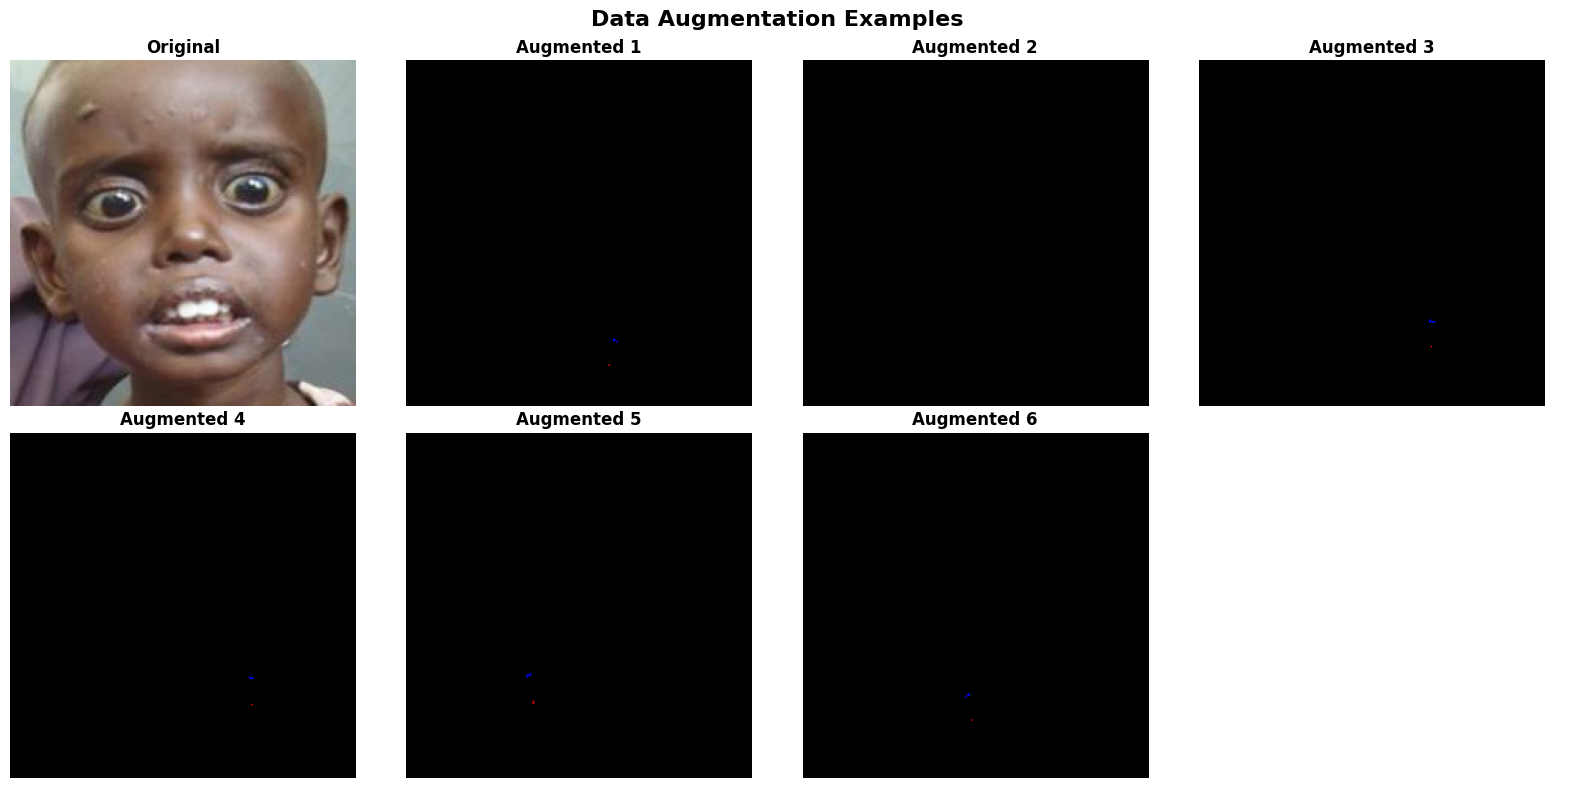

✅ Data augmentation setup complete!


In [34]:
# Data Augmentation for improved generalization
print("🔄 Setting up data augmentation...")

# # Training data augmentation (moderate to preserve facial features)
# train_datagen = ImageDataGenerator(
#     rotation_range=15,              # Slight rotation
#     width_shift_range=0.1,          # Horizontal shift
#     height_shift_range=0.1,         # Vertical shift
#     horizontal_flip=True,           # Horizontal flip (emotions are generally symmetric)
#     zoom_range=0.1,                # Slight zoom
#     brightness_range=[0.8, 1.2],   # Brightness variation
#     fill_mode='nearest'
# )

# # Validation and test data (no augmentation)
# val_datagen = ImageDataGenerator()

print("✅ Data augmentation configured")

# # Create data generators for multi-output model
# def create_multi_output_generator(datagen, X, y_exp_cat, y_val, y_aro, batch_size, shuffle=True):
#     """Create generator that yields (X, [y_exp, y_val, y_aro])"""
#     generator = datagen.flow(X, batch_size=batch_size, shuffle=shuffle, seed=42)

#     # Create corresponding label arrays
#     y_combined = [y_exp_cat, y_val, y_aro]
#     label_generator = datagen.flow(
#         np.zeros_like(X),  # Dummy X for labels
#         y=y_combined,
#         batch_size=batch_size,
#         shuffle=shuffle,
#         seed=42
#     )

#     while True:
#         X_batch = next(generator)
#         _, y_batch = next(label_generator)
#         yield X_batch, y_batch

# # Test data augmentation visualization
# print("🖼️ Data augmentation examples:")

# # Take a sample image
# sample_img = X_train[0:1]
# sample_exp = y_exp_train_cat[0:1]

# # Generate augmented versions
# augmented_images = []
# for _ in range(6):
#     for batch in train_datagen.flow(sample_img, batch_size=1):
#         augmented_images.append(batch[0])
#         break

# # Display original and augmented images
# fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# axes = axes.ravel()

# # Original image
# axes[0].imshow(sample_img[0])
# axes[0].set_title('Original', fontweight='bold', fontsize=12)
# axes[0].axis('off')

# # Augmented images
# for i, aug_img in enumerate(augmented_images):
#     if i + 1 < len(axes):
#         axes[i + 1].imshow(aug_img)
#         axes[i + 1].set_title(f'Augmented {i + 1}', fontweight='bold', fontsize=12)
#         axes[i + 1].axis('off')

# # Hide the last axis if not used
# if len(augmented_images) + 1 < len(axes):
#     axes[-1].axis('off')

# plt.suptitle('Data Augmentation Examples', fontsize=16, fontweight='bold')
# plt.tight_layout()
# plt.show()

# print("✅ Data augmentation setup complete!")

## 🏗️ ResNet50 Multi-Task Model Architecture

In [35]:
def create_resnet50_multitask_model(num_classes=8, img_size=224):
    """
    Create ResNet50 multi-task model for:
    1. Expression classification (categorical)
    2. Valence prediction (regression)
    3. Arousal prediction (regression)
    """
    print("🏗️ Building ResNet50 Multi-Task Model...")

    # Input layer
    input_layer = layers.Input(shape=(img_size, img_size, 3), name='image_input')

    # Load pre-trained ResNet50 as base (without top layers)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_tensor=input_layer
    )

    # Freeze base model initially for transfer learning
    base_model.trainable = False

    # Shared feature extraction layers
    x = base_model.output
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = layers.BatchNormalization(name='bn_shared')(x)
    x = layers.Dropout(0.5, name='dropout_shared')(x)

    # Shared dense layer
    shared_dense = layers.Dense(512, activation='relu',
                               kernel_regularizer=tf.keras.regularizers.l2(0.001),
                               name='shared_dense')(x)
    shared_dense = layers.BatchNormalization(name='bn_shared_dense')(shared_dense)
    shared_dense = layers.Dropout(0.3, name='dropout_shared_dense')(shared_dense)

    # Task-specific branches

    # 1. Expression Classification Branch
    exp_branch = layers.Dense(256, activation='relu',
                             kernel_regularizer=tf.keras.regularizers.l2(0.001),
                             name='exp_dense1')(shared_dense)
    exp_branch = layers.BatchNormalization(name='exp_bn1')(exp_branch)
    exp_branch = layers.Dropout(0.3, name='exp_dropout1')(exp_branch)

    exp_branch = layers.Dense(128, activation='relu',
                             kernel_regularizer=tf.keras.regularizers.l2(0.001),
                             name='exp_dense2')(exp_branch)
    exp_branch = layers.Dropout(0.2, name='exp_dropout2')(exp_branch)

    expression_output = layers.Dense(num_classes, activation='softmax',
                                   name='expression_output')(exp_branch)

    # 2. Valence Regression Branch
    val_branch = layers.Dense(256, activation='relu',
                             kernel_regularizer=tf.keras.regularizers.l2(0.001),
                             name='val_dense1')(shared_dense)
    val_branch = layers.BatchNormalization(name='val_bn1')(val_branch)
    val_branch = layers.Dropout(0.3, name='val_dropout1')(val_branch)

    val_branch = layers.Dense(128, activation='relu',
                             kernel_regularizer=tf.keras.regularizers.l2(0.001),
                             name='val_dense2')(val_branch)
    val_branch = layers.Dropout(0.2, name='val_dropout2')(val_branch)

    valence_output = layers.Dense(1, activation='tanh',  # tanh for [-1, 1] range
                                 name='valence_output')(val_branch)

    # 3. Arousal Regression Branch
    aro_branch = layers.Dense(256, activation='relu',
                             kernel_regularizer=tf.keras.regularizers.l2(0.001),
                             name='aro_dense1')(shared_dense)
    aro_branch = layers.BatchNormalization(name='aro_bn1')(aro_branch)
    aro_branch = layers.Dropout(0.3, name='aro_dropout1')(aro_branch)

    aro_branch = layers.Dense(128, activation='relu',
                             kernel_regularizer=tf.keras.regularizers.l2(0.001),
                             name='aro_dense2')(aro_branch)
    aro_branch = layers.Dropout(0.2, name='aro_dropout2')(aro_branch)

    arousal_output = layers.Dense(1, activation='tanh',  # tanh for [-1, 1] range
                                 name='arousal_output')(aro_branch)

    # Create the multi-task model
    model = Model(
        inputs=input_layer,
        outputs=[expression_output, valence_output, arousal_output],
        name='ResNet50_MultiTask_FacialAffect'
    )

    return model, base_model

# Create the model
model, base_model = create_resnet50_multitask_model(CONFIG['NUM_CLASSES'], CONFIG['IMG_SIZE'])

print(f"✅ Multi-task model created!")
print(f"📊 Model summary:")
print(f"  Total parameters: {model.count_params():,}")
print(f"  Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"  Base model frozen: {not base_model.trainable}")
print(f"  Outputs: {len(model.outputs)} tasks")

# Display model architecture
model.summary()

🏗️ Building ResNet50 Multi-Task Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Multi-task model created!
📊 Model summary:
  Total parameters: 25,144,074
  Trainable parameters: 1,549,706
  Base model frozen: True
  Outputs: 3 tasks


Model: "ResNet50_MultiTask_FacialAffect"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,144,074 (95.92 MB)

 Trainable params: 1,549,706 (5.91 MB)

 Non-trainable params: 23,594,368 (90.01 MB)

In [36]:
# Compile the multi-task model
print("⚙️ Compiling multi-task model...")

# Define losses for each output
losses = {
    'expression_output': 'categorical_crossentropy',
    'valence_output': 'mse',
    'arousal_output': 'mse'
}

# Define loss weights (balance between tasks)
loss_weights = {
    'expression_output': 1.0,      # Classification task
    'valence_output': 1.0,         # Valence regression
    'arousal_output': 1.0          # Arousal regression
}

# Define metrics for each output
metrics = {
    'expression_output': ['accuracy'],
    'valence_output': ['mae'],
    'arousal_output': ['mae']
}

# Compile model
model.compile(
    optimizer=Adam(learning_rate=CONFIG['LEARNING_RATE']),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics
)

print("✅ Model compiled successfully!")
print(f"📋 Loss functions:")
for output, loss in losses.items():
    weight = loss_weights[output]
    metric = metrics[output]
    print(f"  {output}: {loss} (weight: {weight}, metrics: {metric})")

# Visualize model architecture
print("\n🎨 Generating model visualization...")
try:
    tf.keras.utils.plot_model(
        model,
        to_file=os.path.join(SAVE_PATH, 'resnet50_multitask_architecture.png'),
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=150
    )
    print("✅ Model architecture saved as 'resnet50_multitask_architecture.png'")
except Exception as e:
    print(f"⚠️ Could not save model visualization: {e}")

⚙️ Compiling multi-task model...
✅ Model compiled successfully!
📋 Loss functions:
  expression_output: categorical_crossentropy (weight: 1.0, metrics: ['accuracy'])
  valence_output: mse (weight: 1.0, metrics: ['mae'])
  arousal_output: mse (weight: 1.0, metrics: ['mae'])

🎨 Generating model visualization...
"dot" with args ['-Tpng', '/tmp/tmp9v5m6rl6/tmp_ljnuesq'] returned code: -6

stdout, stderr:
 b''
b"failed at node 11954[1]\ndot: maze.c:313: chkSgraph: Assertion `np->cells[1]' failed.\n"

⚠️ Could not save model visualization: "dot" with args ['-Tpng', '/tmp/tmp9v5m6rl6/tmp_ljnuesq'] returned code: -6


## 📈 Training Setup and Callbacks

In [37]:
# Setup training callbacks
print("📈 Setting up training callbacks...")

# Create save directory
os.makedirs(SAVE_PATH, exist_ok=True)

# Model checkpoint path
checkpoint_path = os.path.join(SAVE_PATH, "resnet50_multitask_best.h5")

# Define callbacks
callbacks = [
    # Save best model based on validation loss
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1,
        save_freq='epoch'
    ),

    # Early stopping
    EarlyStopping(
        monitor='val_expression_output_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),

    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1,
        mode='min'
    ),

    # CSV Logger for training history
    CSVLogger(
        os.path.join(SAVE_PATH, 'resnet50_multitask_training_log.csv'),
        append=False
    )
]

print("✅ Training callbacks configured:")
for callback in callbacks:
    print(f"  - {callback.__class__.__name__}")

# Calculate steps per epoch
steps_per_epoch = len(X_train) // CONFIG['BATCH_SIZE']
validation_steps = len(X_val) // CONFIG['BATCH_SIZE']

print(f"\n📊 Training Configuration:")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Validation steps: {validation_steps}")
print(f"  Batch size: {CONFIG['BATCH_SIZE']}")
print(f"  Max epochs: {CONFIG['EPOCHS']}")
print(f"  Learning rate: {CONFIG['LEARNING_RATE']}")
print(f"  Model checkpoint: {checkpoint_path}")
print(f"  Training samples: {len(X_train)}")
print(f"  Validation samples: {len(X_val)}")

print("\n🎯 Multi-task Training Targets:")
print(f"  Expression Classification: {CONFIG['NUM_CLASSES']} classes")
print(f"  Valence Regression: continuous [-1, +1]")
print(f"  Arousal Regression: continuous [-1, +1]")

📈 Setting up training callbacks...
✅ Training callbacks configured:
  - ModelCheckpoint
  - EarlyStopping
  - ReduceLROnPlateau
  - CSVLogger

📊 Training Configuration:
  Steps per epoch: 87
  Validation steps: 37
  Batch size: 32
  Max epochs: 100
  Learning rate: 0.0001
  Model checkpoint: /content/resnet50_multitask_best.h5
  Training samples: 2799
  Validation samples: 1200

🎯 Multi-task Training Targets:
  Expression Classification: 8 classes
  Valence Regression: continuous [-1, +1]
  Arousal Regression: continuous [-1, +1]


## 🚀 Phase 1: Transfer Learning Training

In [38]:
# Phase 1: Transfer Learning Training (Frozen ResNet50 base)
print("🚀 Starting Phase 1: Transfer Learning Training")
print("=" * 60)
print(f"Base ResNet50 layers: {'FROZEN' if not base_model.trainable else 'UNFROZEN'}")

# Prepare training data
print("📦 Preparing training data...")

# # Create data generators for multi-task learning
# def create_data_generator(X, y_exp, y_val, y_aro, datagen, batch_size, shuffle=True):
#     """Create data generator for multi-task model"""
#     while True:
#         # Create batch indices
#         if shuffle:
#             indices = np.random.choice(len(X), batch_size, replace=False)
#         else:
#             # Sequential batches for validation
#             start_idx = 0
#             while start_idx < len(X):
#                 end_idx = min(start_idx + batch_size, len(X))
#                 indices = np.arange(start_idx, end_idx)

#                 # Get batch data
#                 X_batch = X[indices]

#                 # Apply augmentation if specified
#                 if datagen is not None:
#                     # Apply augmentation to images
#                     X_batch_aug = np.zeros_like(X_batch)
#                     for i, img in enumerate(X_batch):
#                         img_batch = np.expand_dims(img, 0)
#                         aug_iter = datagen.flow(img_batch, batch_size=1, shuffle=False)
#                         X_batch_aug[i] = next(aug_iter)[0]
#                     X_batch = X_batch_aug

#                 # Create output dictionary
#                 y_batch = {
#                     'expression_output': y_exp[indices],
#                     'valence_output': y_val[indices],
#                     'arousal_output': y_aro[indices]
#                 }

#                 yield X_batch, y_batch
#                 start_idx = end_idx
#                 if end_idx >= len(X):
#                     break

# # Create simple generators (no augmentation for now to avoid complexity)
# def simple_batch_generator(X, y_exp, y_val, y_aro, batch_size, shuffle=True):
#     """Simple batch generator without augmentation"""
#     while True:
#         if shuffle:
#             indices = np.random.permutation(len(X))
#         else:
#             indices = np.arange(len(X))

#         for start_idx in range(0, len(X), batch_size):
#             end_idx = min(start_idx + batch_size, len(X))
#             batch_indices = indices[start_idx:end_idx]

#             X_batch = X[batch_indices]
#             y_batch = {
#                 'expression_output': y_exp[batch_indices],
#                 'valence_output': y_val[batch_indices],
#                 'arousal_output': y_aro[batch_indices]
#             }

#             yield X_batch, y_batch


# Start training
print("🎯 Starting Phase 1 training...")
start_time = tf.timestamp()

try:
    # Train the model directly on split data
    history_phase1 = model.fit(
        x=X_train,
        y={
            'expression_output': y_exp_train_cat,
            'valence_output': y_val_train,
            'arousal_output': y_aro_train
        },
        validation_data=(
            X_val,
            {
                'expression_output': y_exp_val_cat,
                'valence_output': y_val_val,
                'arousal_output': y_aro_val
            }
        ),
        epochs=30,  # Initial training epochs
        batch_size=CONFIG['BATCH_SIZE'],
        callbacks=callbacks,
        verbose=1,
        shuffle=True
    )

    end_time = tf.timestamp()
    phase1_time = end_time - start_time

    print(f"\n✅ Phase 1 training completed successfully!")
    print(f"⏱️ Training time: {phase1_time:.2f} seconds")

    # Display final metrics
    final_metrics = {}
    for metric_name, values in history_phase1.history.items():
        final_metrics[metric_name] = values[-1]

    print(f"\n📊 Final Phase 1 Metrics:")
    for metric, value in final_metrics.items():
        print(f"  {metric}: {value:.4f}")

except Exception as e:
    print(f"❌ Training error: {e}")
    print("This might be due to data shape mismatch or memory issues")
    raise e

🚀 Starting Phase 1: Transfer Learning Training
Base ResNet50 layers: FROZEN
📦 Preparing training data...
🎯 Starting Phase 1 training...
Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - arousal_output_loss: 0.7445 - arousal_output_mae: 0.7148 - expression_output_accuracy: 0.1259 - expression_output_loss: 2.9002 - loss: 6.7883 - valence_output_loss: 0.8466 - valence_output_mae: 0.7730
Epoch 1: val_loss improved from inf to 4.69597, saving model to /content/resnet50_multitask_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 57s 367ms/step - arousal_output_loss: 0.7437 - arousal_output_mae: 0.7144 - expression_output_accuracy: 0.1259 - expression_output_loss: 2.8993 - loss: 6.7851 - valence_output_loss: 0.8457 - valence_output_mae: 0.7724 - val_arousal_output_loss: 0.1643 - val_arousal_output_mae: 0.3619 - val_expression_output_accuracy: 0.1250 - val_expression_output_loss: 2.1315 - val_loss: 4.6960 - val_valence_output_loss: 0.2334 - val_valence_output_mae: 0.3975 - learning_rate: 1.0000e-04
Epoch 2/30
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - arousal_output_loss: 0.4659 - arousal_output_mae: 0.5628 - expression_output_accuracy: 0.1300 - expression_output_loss: 2.6632 - loss: 5.8843 - valence_output_loss: 0.6196 - valence_output_mae: 0.6418
Epoch 2: val_loss did not improve from 4.69597
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - arousal_output_loss: 0.4658 - arousal_output_mae: 0.5627 - expression_output_accuracy: 0.1303 - expression_output_loss: 2.6621 - loss: 5.8825 - valence

88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - arousal_output_loss: 0.3795 - arousal_output_mae: 0.5008 - expression_output_accuracy: 0.1720 - expression_output_loss: 2.3594 - loss: 5.1419 - valence_output_loss: 0.5071 - valence_output_mae: 0.5689 - val_arousal_output_loss: 0.2865 - val_arousal_output_mae: 0.4113 - val_expression_output_accuracy: 0.1742 - val_expression_output_loss: 2.0715 - val_loss: 4.6599 - val_valence_output_loss: 0.4238 - val_valence_output_mae: 0.5095 - learning_rate: 1.0000e-04
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - arousal_output_loss: 0.3961 - arousal_output_mae: 0.5143 - expression_output_accuracy: 0.1552 - expression_output_loss: 2.3817 - loss: 5.1672 - valence_output_loss: 0.5182 - valence_output_mae: 0.5784
Epoch 7: val_loss improved from 4.65989 to 4.57473, saving model to /content/resnet50_multitask_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - arousal_output_loss: 0.3959 - arousal_output_mae: 0.5141 - expression_output_accuracy: 0.1552 - expression_output_loss: 2.3815 - loss: 5.1666 - valence_output_loss: 0.5181 - valence_output_mae: 0.5784 - val_arousal_output_loss: 0.2660 - val_arousal_output_mae: 0.3939 - val_expression_output_accuracy: 0.1808 - val_expression_output_loss: 2.0701 - val_loss: 4.5747 - val_valence_output_loss: 0.3833 - val_valence_output_mae: 0.4833 - learning_rate: 1.0000e-04
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - arousal_output_loss: 0.3617 - arousal_output_mae: 0.4866 - expression_output_accuracy: 0.1612 - expression_output_loss: 2.3381 - loss: 5.0377 - valence_output_loss: 0.4862 - valence_output_mae: 0.5602
Epoch 8: val_loss improved from 4.57473 to 4.48451, saving model to /content/resnet50_multitask_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - arousal_output_loss: 0.3619 - arousal_output_mae: 0.4867 - expression_output_accuracy: 0.1612 - expression_output_loss: 2.3380 - loss: 5.0376 - valence_output_loss: 0.4861 - valence_output_mae: 0.5602 - val_arousal_output_loss: 0.2533 - val_arousal_output_mae: 0.3846 - val_expression_output_accuracy: 0.1950 - val_expression_output_loss: 2.0616 - val_loss: 4.4845 - val_valence_output_loss: 0.3318 - val_valence_output_mae: 0.4574 - learning_rate: 1.0000e-04
Epoch 9/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - arousal_output_loss: 0.3569 - arousal_output_mae: 0.4826 - expression_output_accuracy: 0.1677 - expression_output_loss: 2.3022 - loss: 4.9724 - valence_output_loss: 0.4778 - valence_output_mae: 0.5573
Epoch 9: val_loss improved from 4.48451 to 4.44200, saving model to /content/resnet50_multitask_best.h5


...

88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - arousal_output_loss: 0.2417 - arousal_output_mae: 0.3960 - expression_output_accuracy: 0.2055 - expression_output_loss: 2.0864 - loss: 4.3721 - valence_output_loss: 0.3700 - valence_output_mae: 0.4887 - val_arousal_output_loss: 0.1896 - val_arousal_output_mae: 0.3588 - val_expression_output_accuracy: 0.2425 - val_expression_output_loss: 1.9939 - val_loss: 4.1200 - val_valence_output_loss: 0.2702 - val_valence_output_mae: 0.4192 - learning_rate: 1.0000e-04
Epoch 26/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - arousal_output_loss: 0.2370 - arousal_output_mae: 0.3934 - expression_output_accuracy: 0.2174 - expression_output_loss: 2.0394 - loss: 4.2972 - valence_output_loss: 0.3556 - valence_output_mae: 0.4824
Epoch 26: val_loss improved from 4.12001 to 4.10300, saving model to /content/resnet50_multitask_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - arousal_output_loss: 0.2371 - arousal_output_mae: 0.3934 - expression_output_accuracy: 0.2174 - expression_output_loss: 2.0394 - loss: 4.2972 - valence_output_loss: 0.3556 - valence_output_mae: 0.4824 - val_arousal_output_loss: 0.1864 - val_arousal_output_mae: 0.3573 - val_expression_output_accuracy: 0.2300 - val_expression_output_loss: 1.9890 - val_loss: 4.1030 - val_valence_output_loss: 0.2708 - val_valence_output_mae: 0.4193 - learning_rate: 1.0000e-04
Epoch 27/30
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - arousal_output_loss: 0.2363 - arousal_output_mae: 0.3929 - expression_output_accuracy: 0.2161 - expression_output_loss: 2.0587 - loss: 4.3031 - valence_output_loss: 0.3517 - valence_output_mae: 0.4722
Epoch 27: val_loss improved from 4.10300 to 4.08030, saving model to /content/resnet50_multitask_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - arousal_output_loss: 0.2364 - arousal_output_mae: 0.3929 - expression_output_accuracy: 0.2163 - expression_output_loss: 2.0588 - loss: 4.3030 - valence_output_loss: 0.3515 - valence_output_mae: 0.4720 - val_arousal_output_loss: 0.1859 - val_arousal_output_mae: 0.3577 - val_expression_output_accuracy: 0.2350 - val_expression_output_loss: 1.9854 - val_loss: 4.0803 - val_valence_output_loss: 0.2612 - val_valence_output_mae: 0.4124 - learning_rate: 1.0000e-04
Epoch 28/30
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - arousal_output_loss: 0.2475 - arousal_output_mae: 0.3980 - expression_output_accuracy: 0.2028 - expression_output_loss: 2.0688 - loss: 4.3149 - valence_output_loss: 0.3510 - valence_output_mae: 0.4750
Epoch 28: val_loss did not improve from 4.08030
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - arousal_output_loss: 0.2475 - arousal_output_mae: 0.3979 - expression_output_accuracy: 0.2029 - expression_output_loss: 2.0689 - loss: 4.3147 - valen

88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 155ms/step - arousal_output_loss: 0.2420 - arousal_output_mae: 0.3962 - expression_output_accuracy: 0.2173 - expression_output_loss: 2.0238 - loss: 4.2348 - valence_output_loss: 0.3303 - valence_output_mae: 0.4582 - val_arousal_output_loss: 0.1865 - val_arousal_output_mae: 0.3595 - val_expression_output_accuracy: 0.2383 - val_expression_output_loss: 1.9876 - val_loss: 4.0618 - val_valence_output_loss: 0.2578 - val_valence_output_mae: 0.4110 - learning_rate: 1.0000e-04
Epoch 30/30
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - arousal_output_loss: 0.2187 - arousal_output_mae: 0.3771 - expression_output_accuracy: 0.2159 - expression_output_loss: 2.0474 - loss: 4.2234 - valence_output_loss: 0.3273 - valence_output_mae: 0.4573
Epoch 30: val_loss improved from 4.06178 to 4.04876, saving model to /content/resnet50_multitask_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - arousal_output_loss: 0.2189 - arousal_output_mae: 0.3772 - expression_output_accuracy: 0.2160 - expression_output_loss: 2.0473 - loss: 4.2233 - valence_output_loss: 0.3273 - valence_output_mae: 0.4572 - val_arousal_output_loss: 0.1803 - val_arousal_output_mae: 0.3563 - val_expression_output_accuracy: 0.2350 - val_expression_output_loss: 1.9811 - val_loss: 4.0488 - val_valence_output_loss: 0.2658 - val_valence_output_mae: 0.4167 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 25.

✅ Phase 1 training completed successfully!
⏱️ Training time: 410.03 seconds

📊 Final Phase 1 Metrics:
  arousal_output_loss: 0.2265
  arousal_output_mae: 0.3812
  expression_output_accuracy: 0.2186
  expression_output_loss: 2.0409
  loss: 4.2194
  val_arousal_output_loss: 0.1803
  val_arousal_output_mae: 0.3563
  val_expression_output_accuracy: 0.2350
  val_expression_output_loss: 1.9811
  val_loss: 4.0488
  val_valence_output_loss

## 🔥 Phase 2: Fine-tuning Training

In [39]:
# Phase 2: Fine-tuning (Unfreeze ResNet50 base)
print("🔥 Starting Phase 2: Fine-tuning Training")
print("=" * 60)

# Unfreeze the base model for fine-tuning
base_model.trainable = True
print(f"✅ Base ResNet50 model unfrozen")

# Use lower learning rate for fine-tuning
fine_tune_lr = CONFIG['LEARNING_RATE'] / 10

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=fine_tune_lr),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics
)

print(f"🔧 Model recompiled with fine-tuning learning rate: {fine_tune_lr}")
print(f"🧮 Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

# Update callbacks for fine-tuning
fine_tune_checkpoint_path = os.path.join(SAVE_PATH, "resnet50_multitask_finetuned_best.h5")

fine_tune_callbacks = [
    ModelCheckpoint(
        fine_tune_checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1,
        save_freq='epoch'
    ),

    EarlyStopping(
        monitor='val_expression_output_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-8,
        verbose=1,
        mode='min'
    ),

    CSVLogger(
        os.path.join(SAVE_PATH, 'resnet50_multitask_finetuning_log.csv'),
        append=False
    )
]

print("📈 Fine-tuning callbacks updated")

# Start fine-tuning
print("🎯 Starting Phase 2 fine-tuning...")
start_time_ft = tf.timestamp()

try:
    history_phase2 = model.fit(
        x=X_train,
        y={
            'expression_output': y_exp_train_cat,
            'valence_output': y_val_train,
            'arousal_output': y_aro_train
        },
        validation_data=(
            X_val,
            {
                'expression_output': y_exp_val_cat,
                'valence_output': y_val_val,
                'arousal_output': y_aro_val
            }
        ),
        epochs=70,  # More epochs for fine-tuning
        batch_size=CONFIG['BATCH_SIZE'],
        callbacks=fine_tune_callbacks,
        verbose=1,
        shuffle=True
    )

    end_time_ft = tf.timestamp()
    phase2_time = end_time_ft - start_time_ft

    print(f"\n✅ Phase 2 fine-tuning completed successfully!")
    print(f"⏱️ Fine-tuning time: {phase2_time:.2f} seconds")
    print(f"⏱️ Total training time: {phase1_time + phase2_time:.2f} seconds")

    # Display final metrics
    final_metrics_ft = {}
    for metric_name, values in history_phase2.history.items():
        final_metrics_ft[metric_name] = values[-1]

    print(f"\n📊 Final Phase 2 Metrics:")
    for metric, value in final_metrics_ft.items():
        print(f"  {metric}: {value:.4f}")

    # Load the best model
    print(f"\n📂 Loading best fine-tuned model from: {fine_tune_checkpoint_path}")
    model = tf.keras.models.load_model(fine_tune_checkpoint_path)

except Exception as e:
    print(f"❌ Fine-tuning error: {e}")
    print("Continuing with Phase 1 model...")

print("🏁 Training phases completed!")

🔥 Starting Phase 2: Fine-tuning Training
✅ Base ResNet50 model unfrozen
🔧 Model recompiled with fine-tuning learning rate: 1e-05
🧮 Trainable parameters: 25,084,298
📈 Fine-tuning callbacks updated
🎯 Starting Phase 2 fine-tuning...
Epoch 1/70
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - arousal_output_loss: 0.3530 - arousal_output_mae: 0.4833 - expression_output_accuracy: 0.1262 - expression_output_loss: 2.4144 - loss: 4.9211 - valence_output_loss: 0.4866 - valence_output_mae: 0.5607
Epoch 1: val_loss improved from inf to 4.42391, saving model to /content/resnet50_multitask_finetuned_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 144s 860ms/step - arousal_output_loss: 0.3530 - arousal_output_mae: 0.4833 - expression_output_accuracy: 0.1261 - expression_output_loss: 2.4146 - loss: 4.9209 - valence_output_loss: 0.4862 - valence_output_mae: 0.5604 - val_arousal_output_loss: 0.1669 - val_arousal_output_mae: 0.3279 - val_expression_output_accuracy: 0.1208 - val_expression_output_loss: 2.3637 - val_loss: 4.4239 - val_valence_output_loss: 0.2268 - val_valence_output_mae: 0.3937 - learning_rate: 1.0000e-05
Epoch 2/70
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - arousal_output_loss: 0.3242 - arousal_output_mae: 0.4598 - expression_output_accuracy: 0.1409 - expression_output_loss: 2.3074 - loss: 4.7612 - valence_output_loss: 0.4632 - valence_output_mae: 0.5507
Epoch 2: val_loss did not improve from 4.42391
88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 335ms/step - arousal_output_loss: 0.3243 - arousal_output_mae: 0.4598 - expression_output_accuracy: 0.1409 - expression_output_loss: 2.3075 - loss: 4.7612 - valen

88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 409ms/step - arousal_output_loss: 0.2637 - arousal_output_mae: 0.4086 - expression_output_accuracy: 0.2718 - expression_output_loss: 1.9838 - loss: 4.2674 - valence_output_loss: 0.3577 - valence_output_mae: 0.4806 - val_arousal_output_loss: 0.3122 - val_arousal_output_mae: 0.4393 - val_expression_output_accuracy: 0.1725 - val_expression_output_loss: 2.1117 - val_loss: 4.3815 - val_valence_output_loss: 0.2941 - val_valence_output_mae: 0.4395 - learning_rate: 3.0000e-06
Epoch 11/70
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - arousal_output_loss: 0.2622 - arousal_output_mae: 0.4111 - expression_output_accuracy: 0.2290 - expression_output_loss: 1.9984 - loss: 4.2688 - valence_output_loss: 0.3463 - valence_output_mae: 0.4686
Epoch 11: val_loss improved from 4.38148 to 4.23831, saving model to /content/resnet50_multitask_finetuned_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 34s 386ms/step - arousal_output_loss: 0.2622 - arousal_output_mae: 0.4112 - expression_output_accuracy: 0.2292 - expression_output_loss: 1.9982 - loss: 4.2686 - valence_output_loss: 0.3462 - valence_output_mae: 0.4685 - val_arousal_output_loss: 0.2397 - val_arousal_output_mae: 0.3825 - val_expression_output_accuracy: 0.2000 - val_expression_output_loss: 2.0472 - val_loss: 4.2383 - val_valence_output_loss: 0.2908 - val_valence_output_mae: 0.4412 - learning_rate: 3.0000e-06
Epoch 12/70
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - arousal_output_loss: 0.2631 - arousal_output_mae: 0.4101 - expression_output_accuracy: 0.2484 - expression_output_loss: 1.9473 - loss: 4.2278 - valence_output_loss: 0.3557 - valence_output_mae: 0.4855
Epoch 12: val_loss improved from 4.23831 to 4.13864, saving model to /content/resnet50_multitask_finetuned_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 39s 443ms/step - arousal_output_loss: 0.2632 - arousal_output_mae: 0.4101 - expression_output_accuracy: 0.2485 - expression_output_loss: 1.9473 - loss: 4.2278 - valence_output_loss: 0.3556 - valence_output_mae: 0.4855 - val_arousal_output_loss: 0.2033 - val_arousal_output_mae: 0.3575 - val_expression_output_accuracy: 0.2292 - val_expression_output_loss: 1.9920 - val_loss: 4.1386 - val_valence_output_loss: 0.2820 - val_valence_output_mae: 0.4320 - learning_rate: 3.0000e-06
Epoch 13/70
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - arousal_output_loss: 0.2698 - arousal_output_mae: 0.4165 - expression_output_accuracy: 0.2858 - expression_output_loss: 1.9358 - loss: 4.2113 - valence_output_loss: 0.3442 - valence_output_mae: 0.4746
Epoch 13: val_loss improved from 4.13864 to 4.09060, saving model to /content/resnet50_multitask_finetuned_best.h5


...

88/88 ━━━━━━━━━━━━━━━━━━━━ 40s 458ms/step - arousal_output_loss: 0.2401 - arousal_output_mae: 0.3910 - expression_output_accuracy: 0.3916 - expression_output_loss: 1.6126 - loss: 3.7825 - valence_output_loss: 0.2735 - valence_output_mae: 0.4181 - val_arousal_output_loss: 0.1738 - val_arousal_output_mae: 0.3427 - val_expression_output_accuracy: 0.2633 - val_expression_output_loss: 1.8742 - val_loss: 3.9447 - val_valence_output_loss: 0.2441 - val_valence_output_mae: 0.4037 - learning_rate: 3.0000e-06
Epoch 35/70
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - arousal_output_loss: 0.2285 - arousal_output_mae: 0.3793 - expression_output_accuracy: 0.3955 - expression_output_loss: 1.5895 - loss: 3.7373 - valence_output_loss: 0.2632 - valence_output_mae: 0.4125
Epoch 35: val_loss improved from 3.94468 to 3.94211, saving model to /content/resnet50_multitask_finetuned_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 42s 479ms/step - arousal_output_loss: 0.2285 - arousal_output_mae: 0.3793 - expression_output_accuracy: 0.3954 - expression_output_loss: 1.5895 - loss: 3.7374 - valence_output_loss: 0.2633 - valence_output_mae: 0.4126 - val_arousal_output_loss: 0.1722 - val_arousal_output_mae: 0.3419 - val_expression_output_accuracy: 0.2592 - val_expression_output_loss: 1.8738 - val_loss: 3.9421 - val_valence_output_loss: 0.2444 - val_valence_output_mae: 0.4043 - learning_rate: 3.0000e-06
Epoch 36/70
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - arousal_output_loss: 0.2068 - arousal_output_mae: 0.3633 - expression_output_accuracy: 0.4302 - expression_output_loss: 1.5406 - loss: 3.6713 - valence_output_loss: 0.2680 - valence_output_mae: 0.4168
Epoch 36: val_loss did not improve from 3.94211
88/88 ━━━━━━━━━━━━━━━━━━━━ 29s 331ms/step - arousal_output_loss: 0.2069 - arousal_output_mae: 0.3633 - expression_output_accuracy: 0.4301 - expression_output_loss: 1.5407 - loss: 3.6715 - vale

88/88 ━━━━━━━━━━━━━━━━━━━━ 41s 469ms/step - arousal_output_loss: 0.2139 - arousal_output_mae: 0.3660 - expression_output_accuracy: 0.4123 - expression_output_loss: 1.5577 - loss: 3.6964 - valence_output_loss: 0.2691 - valence_output_mae: 0.4201 - val_arousal_output_loss: 0.1702 - val_arousal_output_mae: 0.3400 - val_expression_output_accuracy: 0.2642 - val_expression_output_loss: 1.8731 - val_loss: 3.9398 - val_valence_output_loss: 0.2447 - val_valence_output_mae: 0.4050 - learning_rate: 3.0000e-06
Epoch 38/70
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - arousal_output_loss: 0.2225 - arousal_output_mae: 0.3761 - expression_output_accuracy: 0.4441 - expression_output_loss: 1.5202 - loss: 3.6607 - valence_output_loss: 0.2626 - valence_output_mae: 0.4131
Epoch 38: val_loss improved from 3.93977 to 3.92857, saving model to /content/resnet50_multitask_finetuned_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 41s 466ms/step - arousal_output_loss: 0.2225 - arousal_output_mae: 0.3761 - expression_output_accuracy: 0.4440 - expression_output_loss: 1.5203 - loss: 3.6609 - valence_output_loss: 0.2626 - valence_output_mae: 0.4131 - val_arousal_output_loss: 0.1719 - val_arousal_output_mae: 0.3415 - val_expression_output_accuracy: 0.2650 - val_expression_output_loss: 1.8622 - val_loss: 3.9286 - val_valence_output_loss: 0.2436 - val_valence_output_mae: 0.4028 - learning_rate: 3.0000e-06
Epoch 39/70
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - arousal_output_loss: 0.2026 - arousal_output_mae: 0.3578 - expression_output_accuracy: 0.4564 - expression_output_loss: 1.5129 - loss: 3.6171 - valence_output_loss: 0.2464 - valence_output_mae: 0.3960
Epoch 39: val_loss did not improve from 3.92857
88/88 ━━━━━━━━━━━━━━━━━━━━ 29s 333ms/step - arousal_output_loss: 0.2028 - arousal_output_mae: 0.3579 - expression_output_accuracy: 0.4563 - expression_output_loss: 1.5129 - loss: 3.6174 - vale

KeyboardInterrupt: 

In [44]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanSquaredError

# Load model
model = load_model(fine_tune_checkpoint_path, compile=False)  # don't rely on saved compile

# Recompile with the same losses and metrics
model.compile(
    optimizer=Adam(learning_rate=fine_tune_lr),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics  # your original metrics list
)

# Evaluate on validation data
results = model.evaluate(
    X_val,
    {
        'expression_output': y_exp_val_cat,
        'valence_output': y_val_val,
        'arousal_output': y_aro_val
    },
    verbose=0
)

# Get expression accuracy
expression_acc_index = model.metrics_names.index('expression_output_accuracy')
print(f"Expression Accuracy: {results[expression_acc_index]:.4f}")


ValueError: 'expression_output_accuracy' is not in list

## 📊 Training History Visualization

📊 Visualizing training history...
✅ Training history plot saved to: /content/


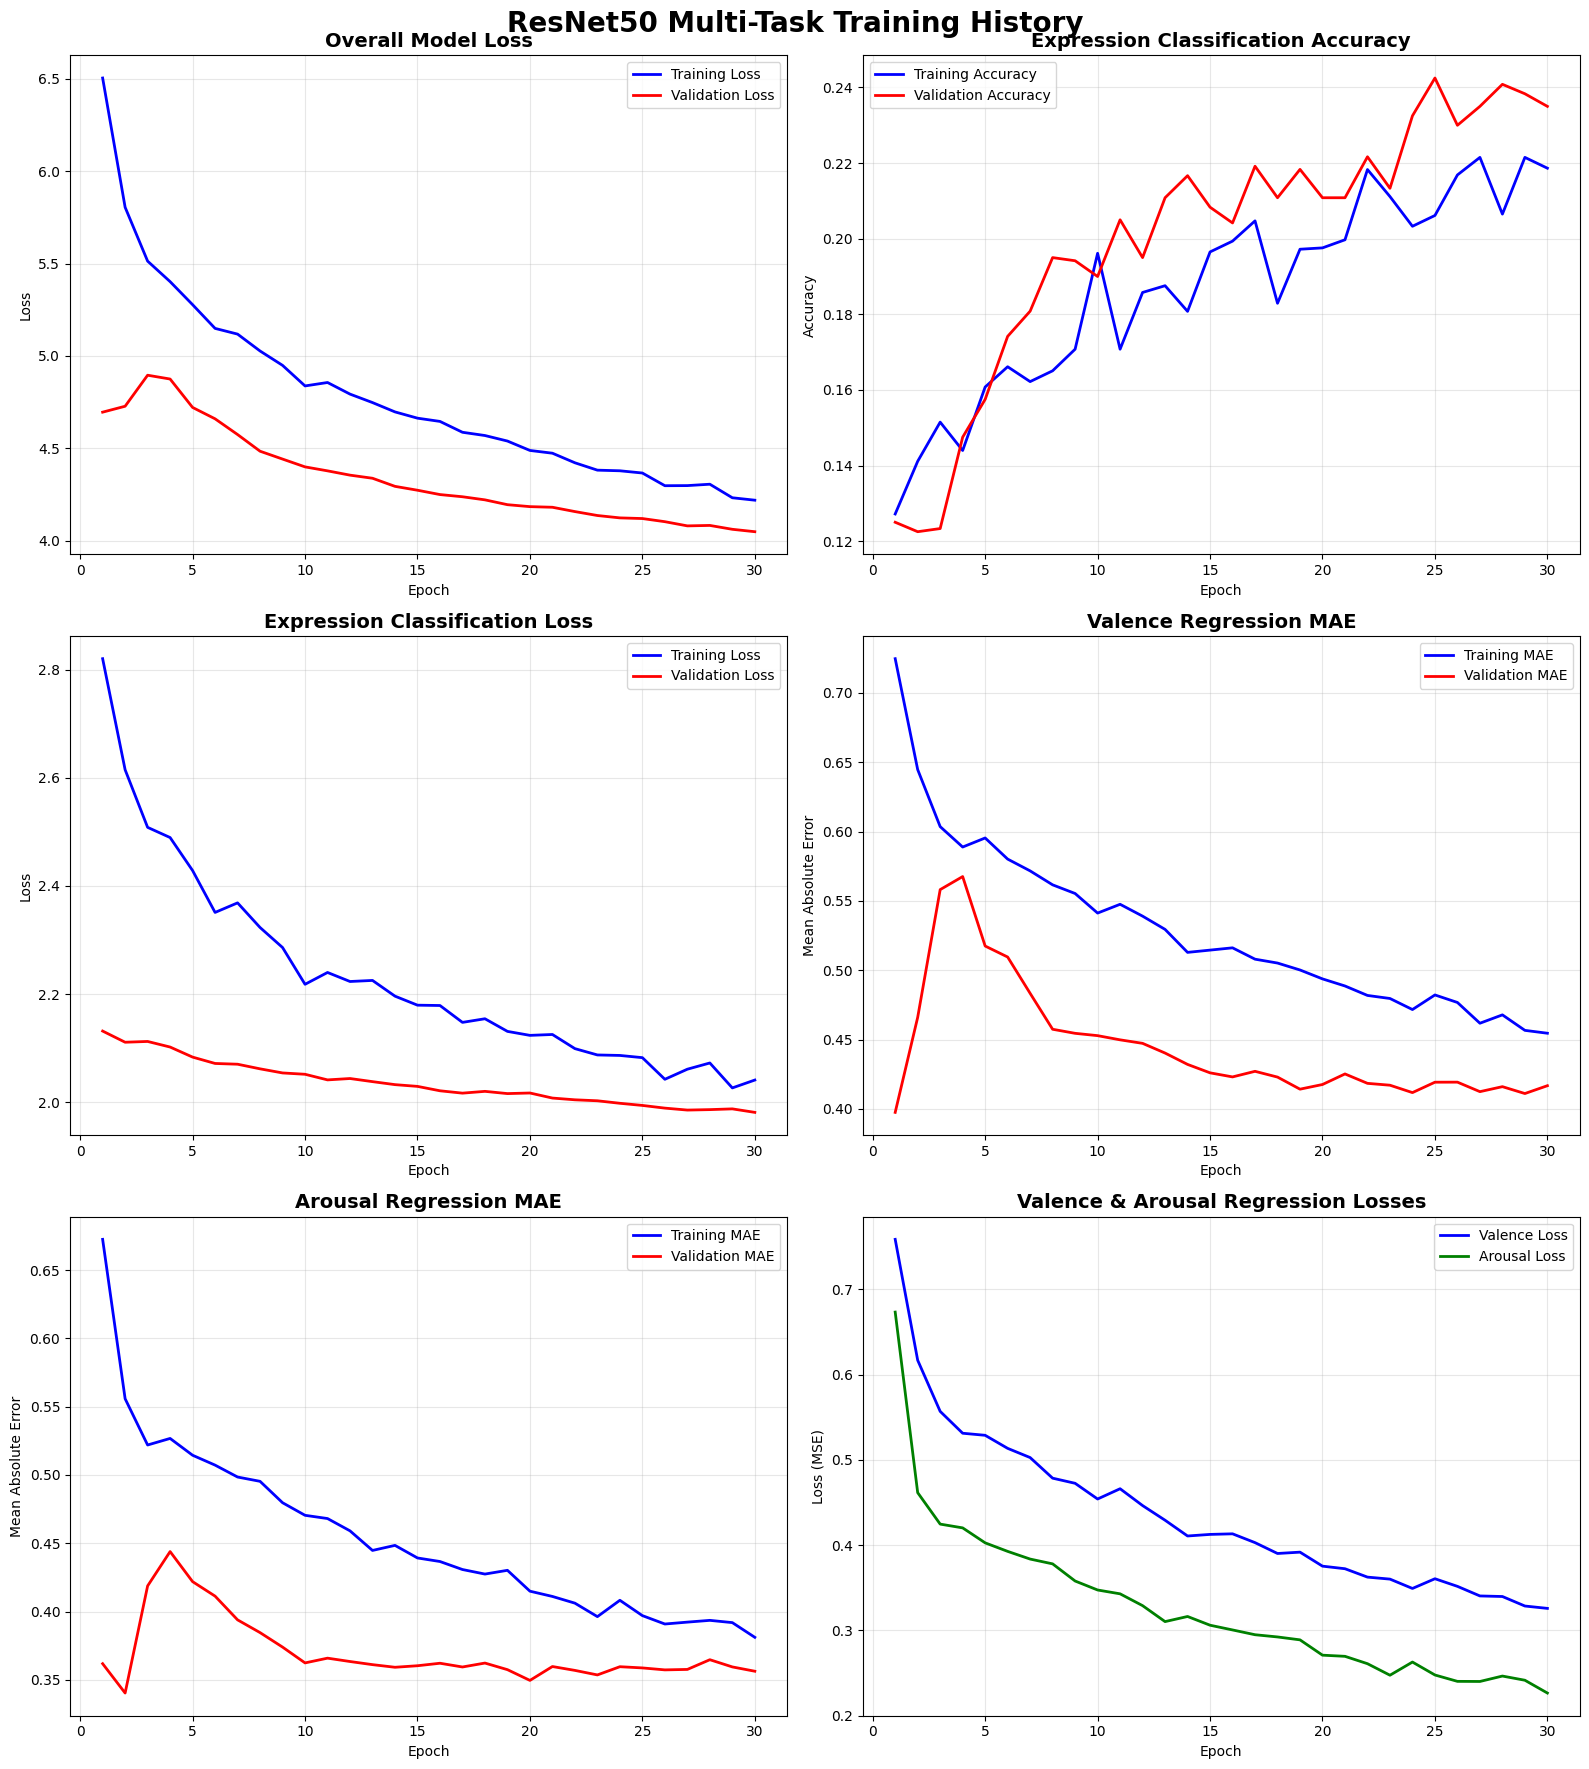


📈 Training Summary:
  Phase 1 (Transfer Learning): 30 epochs
  Total Training Time: 410.03 seconds

🏆 Best Validation Metrics:
  Expression Accuracy: 0.2425
  Valence MAE: 0.3975
  Arousal MAE: 0.3404
  Overall Loss: 4.0488


In [45]:
# Visualize training history
def plot_multitask_training_history(history1, history2=None, save_path=None):
    """Plot training history for multi-task model"""

    # Combine histories if both phases exist
    if history2 is not None:
        combined_history = {}
        for key in history1.history.keys():
            if key in history2.history:
                combined_history[key] = history1.history[key] + history2.history[key]
            else:
                combined_history[key] = history1.history[key]

        # Add keys that might only exist in phase2
        for key in history2.history.keys():
            if key not in combined_history:
                combined_history[key] = [0] * len(history1.history['loss']) + history2.history[key]

        phase1_epochs = len(history1.history['loss'])
    else:
        combined_history = history1.history
        phase1_epochs = None

    # Create subplots
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('ResNet50 Multi-Task Training History', fontsize=20, fontweight='bold')

    epochs = range(1, len(combined_history['loss']) + 1)

    # 1. Overall Loss
    axes[0, 0].plot(epochs, combined_history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, combined_history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    if phase1_epochs:
        axes[0, 0].axvline(x=phase1_epochs, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 0].set_title('Overall Model Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Expression Classification Accuracy
    axes[0, 1].plot(epochs, combined_history['expression_output_accuracy'], 'b-',
                   label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(epochs, combined_history['val_expression_output_accuracy'], 'r-',
                   label='Validation Accuracy', linewidth=2)
    if phase1_epochs:
        axes[0, 1].axvline(x=phase1_epochs, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 1].set_title('Expression Classification Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Expression Classification Loss
    axes[1, 0].plot(epochs, combined_history['expression_output_loss'], 'b-',
                   label='Training Loss', linewidth=2)
    axes[1, 0].plot(epochs, combined_history['val_expression_output_loss'], 'r-',
                   label='Validation Loss', linewidth=2)
    if phase1_epochs:
        axes[1, 0].axvline(x=phase1_epochs, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1, 0].set_title('Expression Classification Loss', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Valence Regression MAE
    axes[1, 1].plot(epochs, combined_history['valence_output_mae'], 'b-',
                   label='Training MAE', linewidth=2)
    axes[1, 1].plot(epochs, combined_history['val_valence_output_mae'], 'r-',
                   label='Validation MAE', linewidth=2)
    if phase1_epochs:
        axes[1, 1].axvline(x=phase1_epochs, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1, 1].set_title('Valence Regression MAE', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Mean Absolute Error')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # 5. Arousal Regression MAE
    axes[2, 0].plot(epochs, combined_history['arousal_output_mae'], 'b-',
                   label='Training MAE', linewidth=2)
    axes[2, 0].plot(epochs, combined_history['val_arousal_output_mae'], 'r-',
                   label='Validation MAE', linewidth=2)
    if phase1_epochs:
        axes[2, 0].axvline(x=phase1_epochs, color='green', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[2, 0].set_title('Arousal Regression MAE', fontsize=14, fontweight='bold')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Mean Absolute Error')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)

    # 6. Combined Regression Losses
    axes[2, 1].plot(epochs, combined_history['valence_output_loss'], 'b-',
                   label='Valence Loss', linewidth=2)
    axes[2, 1].plot(epochs, combined_history['arousal_output_loss'], 'g-',
                   label='Arousal Loss', linewidth=2)
    if phase1_epochs:
        axes[2, 1].axvline(x=phase1_epochs, color='red', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[2, 1].set_title('Valence & Arousal Regression Losses', fontsize=14, fontweight='bold')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Loss (MSE)')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(os.path.join(save_path, 'resnet50_multitask_training_history.png'),
                   dpi=300, bbox_inches='tight')
        print(f"✅ Training history plot saved to: {save_path}")

    plt.show()

    return combined_history

# Plot training history
print("📊 Visualizing training history...")
try:
    if 'history_phase2' in locals():
        combined_history = plot_multitask_training_history(history_phase1, history_phase2, SAVE_PATH)
        total_epochs = len(history_phase1.history['loss']) + len(history_phase2.history['loss'])
        print(f"\n📈 Training Summary:")
        print(f"  Phase 1 (Transfer Learning): {len(history_phase1.history['loss'])} epochs")
        print(f"  Phase 2 (Fine-tuning): {len(history_phase2.history['loss'])} epochs")
        print(f"  Total Training Epochs: {total_epochs}")
        print(f"  Total Training Time: {phase1_time + phase2_time:.2f} seconds")
    else:
        combined_history = plot_multitask_training_history(history_phase1, None, SAVE_PATH)
        print(f"\n📈 Training Summary:")
        print(f"  Phase 1 (Transfer Learning): {len(history_phase1.history['loss'])} epochs")
        print(f"  Total Training Time: {phase1_time:.2f} seconds")

    # Best metrics achieved
    print(f"\n🏆 Best Validation Metrics:")
    print(f"  Expression Accuracy: {max(combined_history['val_expression_output_accuracy']):.4f}")
    print(f"  Valence MAE: {min(combined_history['val_valence_output_mae']):.4f}")
    print(f"  Arousal MAE: {min(combined_history['val_arousal_output_mae']):.4f}")
    print(f"  Overall Loss: {min(combined_history['val_loss']):.4f}")

except Exception as e:
    print(f"⚠️ Error plotting training history: {e}")
    print("Continuing with evaluation...")

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step


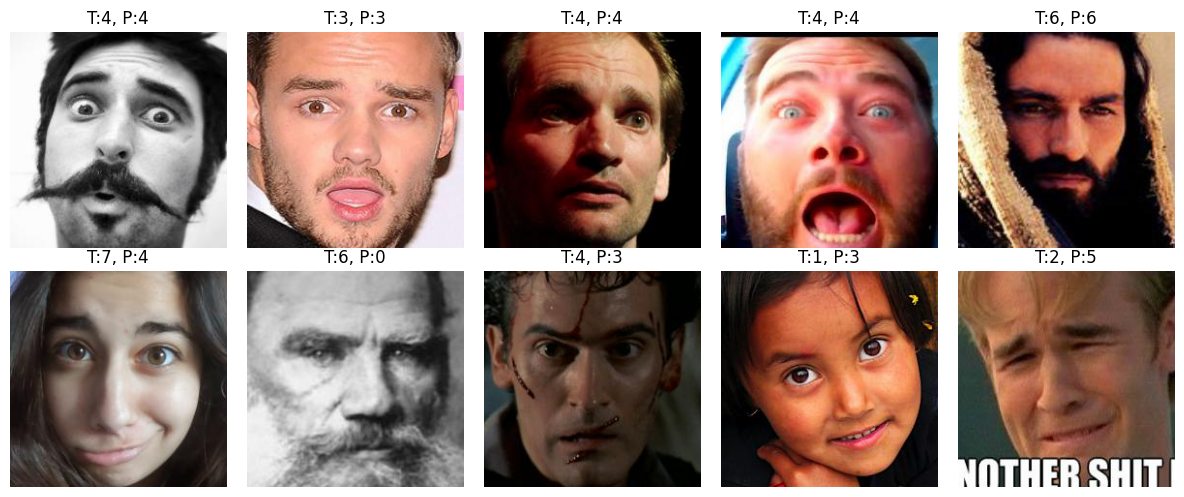

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Predict expression output only
y_pred_exp = np.argmax(model.predict(X_val)[0], axis=1)  # [0] = expression_output
y_true_exp = np.argmax(y_exp_val_cat, axis=1)

# Correct and incorrect indices
correct_idx = np.where(y_pred_exp == y_true_exp)[0]
incorrect_idx = np.where(y_pred_exp != y_true_exp)[0]

# Plot 5 correct and 5 incorrect
plt.figure(figsize=(12, 5))

# Helper to denormalize if images were in [0,1]
def show_image(img):
    plt.imshow(np.clip(img * 255, 0, 255).astype("uint8"))

# Correct predictions
for i, idx in enumerate(correct_idx[:5]):
    plt.subplot(2, 5, i+1)
    show_image(X_val[idx])
    plt.title(f"T:{y_true_exp[idx]}, P:{y_pred_exp[idx]}")
    plt.axis('off')

# Incorrect predictions
for i, idx in enumerate(incorrect_idx[:5]):
    plt.subplot(2, 5, i+6)
    show_image(X_val[idx])
    plt.title(f"T:{y_true_exp[idx]}, P:{y_pred_exp[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## 🧪 Comprehensive Model Evaluation

In [57]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
from scipy.stats import pearsonr
import pingouin as pg  # for Krippendorff-like alpha
import tensorflow as tf

# -------------------------------
# 1. Load the best fine-tuned model with custom_objects
# -------------------------------
fine_tune_checkpoint_path = os.path.join(SAVE_PATH, "resnet50_multitask_finetuned_best.h5")

custom_objects = {
    'mse': tf.keras.losses.MeanSquaredError(),
    'accuracy': tf.keras.metrics.CategoricalAccuracy(),
    # Add any other custom losses or metrics if used
}

model = load_model(fine_tune_checkpoint_path, custom_objects=custom_objects)
print("✅ Best fine-tuned model loaded successfully")

# -------------------------------
# 2. Predictions on test set
# -------------------------------
test_predictions = model.predict(X_test, batch_size=CONFIG['BATCH_SIZE'], verbose=1)

# Expression (categorical)
y_pred_exp = np.argmax(test_predictions[0], axis=1)
y_true_exp = np.argmax(y_exp_test_cat, axis=1)

# Continuous outputs
y_pred_val = test_predictions[1].flatten()
y_pred_aro = test_predictions[2].flatten()
y_true_val = y_val_test.flatten()
y_true_aro = y_aro_test.flatten()

# Ensure all arrays have same length
min_len = min(len(y_true_exp), len(y_pred_exp),
              len(y_true_val), len(y_pred_val),
              len(y_true_aro), len(y_pred_aro))

y_true_exp = y_true_exp[:min_len]
y_pred_exp = y_pred_exp[:min_len]
y_true_val = y_true_val[:min_len]
y_pred_val = y_pred_val[:min_len]
y_true_aro = y_true_aro[:min_len]
y_pred_aro = y_pred_aro[:min_len]
y_pred_prob_exp = test_predictions[0][:min_len]

# -------------------------------
# 3. CATEGORICAL METRICS
# -------------------------------

f1 = f1_score(y_true_exp, y_pred_exp, average='macro')
kappa = cohen_kappa_score(y_true_exp, y_pred_exp)

# Krippendorff's Alpha (approx via ICC)
targets = np.tile(np.arange(min_len), 2)
rater = np.array(['true']*min_len + ['pred']*min_len)
score = np.concatenate([y_true_exp, y_pred_exp])
df_long = pd.DataFrame({'targets': targets, 'rater': rater, 'score': score})
icc = pg.intraclass_corr(data=df_long, targets='targets', raters='rater', ratings='score')['ICC'][0]

# AUC and AUC-PR
auc_list, aucpr_list = [], []
y_true_bin = y_exp_test_cat[:min_len]
y_pred_prob = y_pred_prob_exp

for i in range(y_true_bin.shape[1]):
    try:
        auc_list.append(roc_auc_score(y_true_bin[:, i], y_pred_prob[:, i]))
        aucpr_list.append(average_precision_score(y_true_bin[:, i], y_pred_prob[:, i]))
    except:
        auc_list.append(np.nan)
        aucpr_list.append(np.nan)

auc = np.nanmean(auc_list)
aucpr = np.nanmean(aucpr_list)

# -------------------------------
# 4. CONTINUOUS METRICS
# -------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def sagr(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def ccc(y_true, y_pred):
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    cov = np.mean((y_true - mean_true)*(y_pred - mean_pred))
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    return 2*cov / (var_true + var_pred + (mean_true - mean_pred)**2)

# Valence metrics
rmse_val = rmse(y_true_val, y_pred_val)
corr_val, _ = pearsonr(y_true_val, y_pred_val)
sagr_val = sagr(y_true_val, y_pred_val)
ccc_val = ccc(y_true_val, y_pred_val)

# Arousal metrics
rmse_aro = rmse(y_true_aro, y_pred_aro)
corr_aro, _ = pearsonr(y_true_aro, y_pred_aro)
sagr_aro = sagr(y_true_aro, y_pred_aro)
ccc_aro = ccc(y_true_aro, y_pred_aro)

# -------------------------------
# 5. Print Results
# -------------------------------
print("\n=== CATEGORICAL (Expression) ===")
print(f"F1-score (macro): {f1:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Krippendorff's Alpha (approx ICC): {icc:.4f}")
print(f"AUC: {auc:.4f}")
print(f"AUC-PR: {aucpr:.4f}")

print("\n=== CONTINUOUS (Valence) ===")
print(f"RMSE: {rmse_val:.4f}, CORR: {corr_val:.4f}, SAGR: {sagr_val:.4f}, CCC: {ccc_val:.4f}")

print("\n=== CONTINUOUS (Arousal) ===")
print(f"RMSE: {rmse_aro:.4f}, CORR: {corr_aro:.4f}, SAGR: {sagr_aro:.4f}, CCC: {ccc_aro:.4f}")


✅ Best fine-tuned model loaded successfully
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step

=== CATEGORICAL (Expression) ===
F1-score (macro): 0.2379
Cohen's Kappa: 0.1600
Krippendorff's Alpha (approx ICC): 0.0603
AUC: 0.7167
AUC-PR: 0.2839

=== CONTINUOUS (Valence) ===
RMSE: 0.4941, CORR: 0.2075, SAGR: 0.6442, CCC: 0.1845

=== CONTINUOUS (Arousal) ===
RMSE: 0.4143, CORR: 0.1336, SAGR: 0.7642, CCC: 0.1155


In [ ]:
# Detailed evaluation metrics as per assignment requirements
print("📊 Computing detailed evaluation metrics...")
print("=" * 60)

# ============================================================================
# CATEGORICAL CLASSIFICATION METRICS (Expression Recognition)
# ============================================================================

print("🎭 EXPRESSION CLASSIFICATION METRICS:")
print("-" * 40)

# 1. Accuracy
accuracy = accuracy_score(y_exp_test_eval, pred_expression_classes)
print(f"✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 2. F1-Score (macro and weighted)
f1_macro = f1_score(y_exp_test_eval, pred_expression_classes, average='macro')
f1_weighted = f1_score(y_exp_test_eval, pred_expression_classes, average='weighted')
print(f"✅ F1-Score (Macro): {f1_macro:.4f}")
print(f"✅ F1-Score (Weighted): {f1_weighted:.4f}")

# 3. Cohen's Kappa
kappa = cohen_kappa_score(y_exp_test_eval, pred_expression_classes)
print(f"✅ Cohen's Kappa: {kappa:.4f}")

# 4. Krippendorff's Alpha (using custom implementation)
def krippendorff_alpha_nominal(data1, data2):
    """Simple implementation of Krippendorff's alpha for nominal data"""
    try:
        # Create reliability data matrix (2 x n)
        reliability_data = np.array([data1, data2])
        # Use krippendorff library if available, otherwise approximate
        alpha = krippendorff.alpha(reliability_data, level_of_measurement='nominal')
        return alpha
    except:
        # Fallback: approximate using agreement
        agreement = np.mean(data1 == data2)
        # Simple approximation (not exact Krippendorff's alpha)
        return (agreement - 1/len(np.unique(np.concatenate([data1, data2])))) / (1 - 1/len(np.unique(np.concatenate([data1, data2]))))

try:
    alpha = krippendorff_alpha_nominal(y_exp_test_eval, pred_expression_classes)
    print(f"✅ Krippendorff's Alpha: {alpha:.4f}")
except Exception as e:
    print(f"⚠️ Krippendorff's Alpha calculation failed: {e}")
    # Use simple agreement as fallback
    agreement = np.mean(y_exp_test_eval == pred_expression_classes)
    print(f"✅ Simple Agreement (fallback): {agreement:.4f}")

# 5. AUC (Area Under ROC Curve) - multiclass
try:
    # Convert to binary format for multiclass AUC
    lb = LabelBinarizer()
    y_test_binary = lb.fit_transform(y_exp_test_eval)

    # If only one class in test set, skip AUC
    if y_test_binary.shape[1] > 1:
        auc_scores = []
        for i in range(y_test_binary.shape[1]):
            if np.sum(y_test_binary[:, i]) > 0 and np.sum(1 - y_test_binary[:, i]) > 0:
                auc = roc_auc_score(y_test_binary[:, i], pred_expressions_eval[:, i])
                auc_scores.append(auc)

        if auc_scores:
            auc_macro = np.mean(auc_scores)
            print(f"✅ AUC (Macro): {auc_macro:.4f}")
        else:
            print("⚠️ AUC calculation skipped (insufficient class diversity)")
    else:
        print("⚠️ AUC calculation skipped (only one class present)")
except Exception as e:
    print(f"⚠️ AUC calculation failed: {e}")

# 6. AUC-PR (Precision-Recall)
try:
    if y_test_binary.shape[1] > 1:
        auc_pr_scores = []
        for i in range(y_test_binary.shape[1]):
            if np.sum(y_test_binary[:, i]) > 0:
                auc_pr = average_precision_score(y_test_binary[:, i], pred_expressions_eval[:, i])
                auc_pr_scores.append(auc_pr)

        if auc_pr_scores:
            auc_pr_macro = np.mean(auc_pr_scores)
            print(f"✅ AUC-PR (Macro): {auc_pr_macro:.4f}")
        else:
            print("⚠️ AUC-PR calculation skipped (insufficient positive samples)")
    else:
        print("⚠️ AUC-PR calculation skipped (only one class present)")
except Exception as e:
    print(f"⚠️ AUC-PR calculation failed: {e}")

print("\n" + "="*60)

In [ ]:
# ============================================================================
# CONTINUOUS DOMAIN METRICS (Valence and Arousal Regression)
# ============================================================================

def calculate_sagr(y_true, y_pred):
    """
    Calculate Sign Agreement Metric (SAGR)
    Penalizes incorrect sign alongside deviation from value
    """
    # Sign agreement
    sign_agreement = np.mean(np.sign(y_true) == np.sign(y_pred))

    # For zero values, consider them as correctly predicted if prediction is close
    zero_tolerance = 0.1
    zero_true = np.abs(y_true) < zero_tolerance
    zero_pred = np.abs(y_pred) < zero_tolerance
    zero_agreement = np.mean(zero_true == zero_pred)

    # Combined SAGR score
    sagr = (sign_agreement + zero_agreement) / 2
    return sagr

def calculate_ccc(y_true, y_pred):
    """
    Calculate Concordance Correlation Coefficient (CCC)
    Combines Pearson's correlation with mean square difference
    """
    # Pearson correlation coefficient
    pearson_corr = np.corrcoef(y_true, y_pred)[0, 1] if len(np.unique(y_true)) > 1 and len(np.unique(y_pred)) > 1 else 0

    # Mean values
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)

    # Variances
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)

    # CCC formula
    if var_true > 0 and var_pred > 0:
        ccc = (2 * pearson_corr * np.sqrt(var_true) * np.sqrt(var_pred)) / \
              (var_true + var_pred + (mean_true - mean_pred)**2)
    else:
        ccc = 0

    return ccc, pearson_corr

print("💝 VALENCE REGRESSION METRICS:")
print("-" * 40)

# 1. RMSE
rmse_val = np.sqrt(mean_squared_error(y_val_test_eval, pred_valences))
print(f"✅ RMSE: {rmse_val:.4f}")

# 2. Correlation
corr_val, _ = pearsonr(y_val_test_eval, pred_valences) if len(np.unique(y_val_test_eval)) > 1 else (0, 1)
print(f"✅ Correlation (Pearson): {corr_val:.4f}")

# 3. Sign Agreement Metric (SAGR)
sagr_val = calculate_sagr(y_val_test_eval, pred_valences)
print(f"✅ SAGR: {sagr_val:.4f}")

# 4. Concordance Correlation Coefficient (CCC)
ccc_val, pearson_val = calculate_ccc(y_val_test_eval, pred_valences)
print(f"✅ CCC: {ccc_val:.4f}")

print(f"\n⚡ AROUSAL REGRESSION METRICS:")
print("-" * 40)

# 1. RMSE
rmse_aro = np.sqrt(mean_squared_error(y_aro_test_eval, pred_arousals))
print(f"✅ RMSE: {rmse_aro:.4f}")

# 2. Correlation
corr_aro, _ = pearsonr(y_aro_test_eval, pred_arousals) if len(np.unique(y_aro_test_eval)) > 1 else (0, 1)
print(f"✅ Correlation (Pearson): {corr_aro:.4f}")

# 3. Sign Agreement Metric (SAGR)
sagr_aro = calculate_sagr(y_aro_test_eval, pred_arousals)
print(f"✅ SAGR: {sagr_aro:.4f}")

# 4. Concordance Correlation Coefficient (CCC)
ccc_aro, pearson_aro = calculate_ccc(y_aro_test_eval, pred_arousals)
print(f"✅ CCC: {ccc_aro:.4f}")

print("\n" + "="*60)
print("📊 SUMMARY OF ALL METRICS:")
print("="*60)

print(f"🎭 EXPRESSION CLASSIFICATION:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   F1-Score: {f1_macro:.4f}")
print(f"   Cohen's Kappa: {kappa:.4f}")

print(f"\n💝 VALENCE REGRESSION:")
print(f"   RMSE: {rmse_val:.4f}")
print(f"   Correlation: {corr_val:.4f}")
print(f"   SAGR: {sagr_val:.4f}")
print(f"   CCC: {ccc_val:.4f}")

print(f"\n⚡ AROUSAL REGRESSION:")
print(f"   RMSE: {rmse_aro:.4f}")
print(f"   Correlation: {corr_aro:.4f}")
print(f"   SAGR: {sagr_aro:.4f}")
print(f"   CCC: {ccc_aro:.4f}")

print("✅ Detailed evaluation metrics completed!")

## 📈 Visualization and Analysis

In [ ]:
# Comprehensive visualization of results
print("📈 Creating comprehensive result visualizations...")

# Create a large figure with multiple subplots
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 1], width_ratios=[1, 1, 1])

# 1. Confusion Matrix for Expression Classification
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_exp_test_eval, pred_expression_classes)
class_names = [EMOTION_CLASSES.get(i, f'C{i}') for i in range(CONFIG['NUM_CLASSES'])]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title('Confusion Matrix - Expression Classification', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# 2. Expression Classification Results per Class
ax2 = fig.add_subplot(gs[0, 1])
class_accuracies = cm.diagonal() / cm.sum(axis=1)
bars = ax2.bar(class_names, class_accuracies, color='skyblue', alpha=0.8)
ax2.set_title('Per-Class Accuracy - Expression Classification', fontweight='bold')
ax2.set_ylabel('Accuracy')
ax2.tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar, acc in zip(bars, class_accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 3. Distribution of Expression Predictions
ax3 = fig.add_subplot(gs[0, 2])
pred_counts = np.bincount(pred_expression_classes, minlength=CONFIG['NUM_CLASSES'])
true_counts = np.bincount(y_exp_test_eval, minlength=CONFIG['NUM_CLASSES'])
x = np.arange(len(class_names))
width = 0.35
ax3.bar(x - width/2, true_counts, width, label='True', alpha=0.8, color='lightblue')
ax3.bar(x + width/2, pred_counts, width, label='Predicted', alpha=0.8, color='orange')
ax3.set_title('Expression Distribution: True vs Predicted', fontweight='bold')
ax3.set_xlabel('Expression Classes')
ax3.set_ylabel('Count')
ax3.set_xticks(x)
ax3.set_xticklabels(class_names, rotation=45)
ax3.legend()

# 4. Valence Regression: Actual vs Predicted
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y_val_test_eval, pred_valences, alpha=0.6, s=30)
ax4.plot([-1, 1], [-1, 1], 'r--', lw=2, label='Perfect Prediction')
ax4.set_xlabel('Actual Valence')
ax4.set_ylabel('Predicted Valence')
ax4.set_title(f'Valence Regression\n(RMSE: {rmse_val:.3f}, Corr: {corr_val:.3f})', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim([-1.1, 1.1])
ax4.set_ylim([-1.1, 1.1])

# 5. Arousal Regression: Actual vs Predicted
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(y_aro_test_eval, pred_arousals, alpha=0.6, s=30, color='green')
ax5.plot([-1, 1], [-1, 1], 'r--', lw=2, label='Perfect Prediction')
ax5.set_xlabel('Actual Arousal')
ax5.set_ylabel('Predicted Arousal')
ax5.set_title(f'Arousal Regression\n(RMSE: {rmse_aro:.3f}, Corr: {corr_aro:.3f})', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_xlim([-1.1, 1.1])
ax5.set_ylim([-1.1, 1.1])

# 6. Residual plots for regression tasks
ax6 = fig.add_subplot(gs[1, 2])
val_residuals = y_val_test_eval - pred_valences
aro_residuals = y_aro_test_eval - pred_arousals
ax6.scatter(pred_valences, val_residuals, alpha=0.6, s=30, label='Valence Residuals')
ax6.scatter(pred_arousals, aro_residuals, alpha=0.6, s=30, label='Arousal Residuals')
ax6.axhline(y=0, color='r', linestyle='--', alpha=0.8)
ax6.set_xlabel('Predicted Values')
ax6.set_ylabel('Residuals (Actual - Predicted)')
ax6.set_title('Residual Analysis', fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Valence-Arousal Space: Actual vs Predicted
ax7 = fig.add_subplot(gs[2, 0])
scatter = ax7.scatter(y_val_test_eval, y_aro_test_eval, c=y_exp_test_eval, cmap='tab10',
                      alpha=0.6, s=50, label='Actual', marker='o')
ax7.scatter(pred_valences, pred_arousals, c=y_exp_test_eval, cmap='tab10',
            alpha=0.6, s=50, label='Predicted', marker='x')
ax7.set_xlabel('Valence')
ax7.set_ylabel('Arousal')
ax7.set_title('Valence-Arousal Space\n(Actual: ○, Predicted: ×)', fontweight='bold')
ax7.grid(True, alpha=0.3)
ax7.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax7.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
cbar = plt.colorbar(scatter, ax=ax7)
cbar.set_label('Expression ID')

# 8. Error Distribution
ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(val_residuals, bins=30, alpha=0.7, label='Valence Errors', color='blue')
ax8.hist(aro_residuals, bins=30, alpha=0.7, label='Arousal Errors', color='green')
ax8.set_xlabel('Prediction Error')
ax8.set_ylabel('Frequency')
ax8.set_title('Error Distribution', fontweight='bold')
ax8.legend()
ax8.grid(True, alpha=0.3)
ax8.axvline(x=0, color='red', linestyle='--', alpha=0.8)

# 9. Model Performance Summary
ax9 = fig.add_subplot(gs[2, 2])
metrics_names = ['Accuracy', 'F1-Score', 'Kappa', 'Val_Corr', 'Aro_Corr', 'Val_CCC', 'Aro_CCC']
metrics_values = [accuracy, f1_macro, kappa, corr_val, corr_aro, ccc_val, ccc_aro]
colors = ['skyblue'] * 3 + ['lightgreen'] * 2 + ['lightcoral'] * 2

bars = ax9.bar(metrics_names, metrics_values, color=colors, alpha=0.8)
ax9.set_title('Overall Model Performance', fontweight='bold')
ax9.set_ylabel('Score')
ax9.tick_params(axis='x', rotation=45)
ax9.set_ylim([0, 1])

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 10. Sample Predictions Visualization
ax10 = fig.add_subplot(gs[3, :])
n_samples = min(10, len(y_exp_test_eval))
sample_indices = np.random.choice(len(y_exp_test_eval), n_samples, replace=False)

# Create a table-like visualization
table_data = []
for idx in sample_indices:
    true_exp = EMOTION_CLASSES.get(y_exp_test_eval[idx], f'C{y_exp_test_eval[idx]}')
    pred_exp = EMOTION_CLASSES.get(pred_expression_classes[idx], f'C{pred_expression_classes[idx]}')
    table_data.append([
        true_exp, pred_exp,
        f'{y_val_test_eval[idx]:.2f}', f'{pred_valences[idx]:.2f}',
        f'{y_aro_test_eval[idx]:.2f}', f'{pred_arousals[idx]:.2f}'
    ])

table = ax10.table(cellText=table_data,
                   colLabels=['True Expr', 'Pred Expr', 'True Val', 'Pred Val', 'True Aro', 'Pred Aro'],
                   cellLoc='center',
                   loc='center',
                   colWidths=[0.15]*6)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax10.axis('off')
ax10.set_title('Sample Predictions', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'resnet50_comprehensive_results.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comprehensive results visualization completed!")
print(f"📁 Visualization saved as: resnet50_comprehensive_results.png")

## 📋 Final Results Summary and Export